**Recipe recommendation with two towers**

Ratings come from `new_dataset_recommendation_df`, loaded from
`input_stage2/recipe_user_ratings.csv`. Run `map_recipe_nutrients.ipynb` first when rebuilding
that CSV: each rating must retain its original `RAW_interactions.csv` **date**. Minutes, steps,
and descriptions come from `input/RecipeInteraction/RAW_recipes.csv`.

The towers follow `two-tower-embeddings.md`, and the training loop `two-tower-implementation.md`:

```text
ratings 1–5★ (rows with rating 0, a review without stars, are cut)
    → users with ≥ 6 ratings, recipes with ≥ 5 (the two filters repeat until both hold)
    → per-user split: each user's last 2 ratings (by date) are validation
    → rows: one per liked rating (3–5★), ≤ 50 per user per epoch; 1–2★ ratings stay in histories
    → item tower: one projection per feature group (nutrition, price, time, text, ingredients,
                  adjectives, verbs, tags, recipe ID) → concat → MLP → L2-normalize
    → user tower: the item tower on the user's history recipes → rating × recency weighted mean
                  of the liked ones + a GRU over the whole history → MLP → L2-normalize
    → loss: in-batch softmax, U·Iᵀ / τ − log q, other liked recipes of the row's user masked
    → evaluate: Recall@K on held-out liked recipes vs a popularity baseline
    → serve: precomputed item vectors → inner-product index (FAISS) → top K per user
```

**Item tower.** Every feature group gets its own projection to `PART_DIM` (32) before the
concat, so no group swamps the others. Ingredients, adjectives, and verbs are lowercased,
lemmatized, and singularized, and recipe tags come from `RAW_recipes.csv`; each distinct term is embedded once by a frozen pretrained
sentence encoder (all-MiniLM-L6-v2), and a recipe's field is the mean of its terms' vectors
(`EmbeddingBag`) followed by a learned linear layer. Nutrition, price, and time go through
`log1p`, a clip at the 99.5th percentile, and standardization on training recipes. The name +
description text is a frozen BERT embedding. The recipe ID has its own embedding with ID dropout
(0.3), so the content groups carry the rarely rated recipes.

**User tower.** No user-ID embedding: a user is described by the recipes they rated. The shared
item tower encodes each history recipe; the liked ones are pooled by a mean weighted by rating
(3★ 1, 4★ 2, 5★ 3) and recency (half weight per 180 days), and a GRU reads the whole history,
dislikes included. A user with no history gets the most-liked recipes instead.

Both towers are **L2-normalized**, so their dot product is the cosine similarity, consistent with
the in-batch softmax and FAISS. The two-tower only retrieves: rating predictions come from the
LightGBM reranker (`model_training_reranker.ipynb`), which uses the two-tower score as a feature.
Not used: review text (averaging it per recipe would leak the held-out reviews into item
features).

In [1]:
# Run once if these packages are missing, then restart the notebook kernel.
# %pip install torch transformers==5.17.0 sentence-transformers nltk numpy pandas scikit-learn joblib matplotlib
import json
import random
import sys
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import torch
from IPython.display import display

**Configuration**

Data and labels: only 1–5★ ratings are used (`build_interactions` cuts rows with rating 0). Users
need `MIN_USER_RATINGS = 6` ratings and recipes `MIN_RECIPE_RATINGS = 5` (1 keeps every recipe);
each user's last `HOLDOUT_PER_USER = 2` ratings are held out. Ratings of 3 or more are positives
(`POSITIVE_MIN_RATING`, with the definitions below).

Recipe features: `TERM_MODEL` (all-MiniLM-L6-v2, pinned to `TERM_REVISION`) embeds every
normalized ingredient, adjective, verb, and tag term once; `BERT_MODEL` embeds each recipe's name +
description (`TEXT_EMBEDDING_DIM`, `TEXT_MAX_LENGTH`). Nutrition, price, and time are `log1p`,
clipped at the `CLIP_QUANTILE = 0.995` quantile, and standardized on training recipes. Each
missing price contributes **±$2** (`MISSING_PRICE_ERROR_DOLLARS`) of uncertainty, never an
imputed cost; nested fuzzy-price dictionaries are summed recursively. Nutrition columns keep the
input CSV's names and values, each averaged separately per recipe; repeated rating rows never
weight a recipe twice.

Model and training (`two-tower-embeddings.md`, `two-tower-implementation.md`): `EMBEDDING_DIM = 64`,
`PART_DIM = 32` per feature group, `HIDDEN_DIM = 128`, `ITEM_ID_DROPOUT = 0.3`, and
`MIN_ITEM_RATINGS_FOR_ID = 5`. `NORMALIZE_EMBEDDINGS = True` L2-normalizes both towers, so their
dot product is the cosine similarity. The in-batch softmax uses `BATCH_SIZE = 512`,
`IN_BATCH_TEMPERATURE = 0.1` (τ; tune within 0.02–0.2), and `MAX_ROWS_PER_USER = 50`.
`RECENCY_HALF_LIFE_DAYS = 180` halves a history rating's weight in the pooled user vector per 180
days of age. `RECALL_KS` and `RECALL_SAMPLE_USERS` control Recall@K. `NUM_WORKERS` is 2 on Linux
(Colab, Kaggle) and 0 on macOS and Windows, where DataLoader workers can't load classes defined
in a notebook. `THIN_FIVE_STAR_TARGETS` (off) would thin the 5★ training rows of users with many.

In [2]:
RANDOM_STATE = 42
BERT_MODEL = "bert-base-uncased"  # Frozen encoder of each recipe's name + description.
BERT_REVISION = "86b5e0934494bd15c9632b12f734a8a67f723594"
TERM_MODEL = "sentence-transformers/all-MiniLM-L6-v2"  # Frozen vector per ingredient, adjective, verb, and tag.
TERM_REVISION = "1110a243fdf4706b3f48f1d95db1a4f5529b4d41"
TERM_BATCH_SIZE = 256
TEXT_EMBEDDING_DIM = 128  # Name + description BERT embedding, reduced by SVD.
TEXT_MAX_LENGTH = 64  # Tokens of "name. description" (median description is 27 words).
TEXT_BATCH_SIZE = 128
NUTRITION_CLUSTERS = 32
CLIP_QUANTILE = 0.995  # Nutrition, price, and time: log1p, clip at this quantile, standardize.
MISSING_PRICE_ERROR_DOLLARS = 2.0
RECENCY_HALF_LIFE_DAYS = 180.0
MAX_HISTORY = 64
MIN_USER_RATINGS = 6  # Users with fewer 1-5 star ratings are dropped, with their rows.
MIN_RECIPE_RATINGS = 5  # Recipes with fewer ratings are dropped too (1 keeps every recipe).
HOLDOUT_PER_USER = 2  # Each user's last N ratings (by date) are held out for validation.
EMBEDDING_DIM = 64
PART_DIM = 32  # Every item feature group is projected to this size before the concat.
HIDDEN_DIM = 128
ITEM_ID_DROPOUT = 0.3  # Share of training rows whose recipe ID is hidden, so the content groups carry weight.
MIN_ITEM_RATINGS_FOR_ID = 5  # Rarer recipes share the zero PAD row and rely on content alone.
NORMALIZE_EMBEDDINGS = True  # L2-normalized towers: the dot product is the cosine similarity.
EPOCHS = 20
BATCH_SIZE = 512  # Larger batches mean more in-batch negatives.
LEARNING_RATE = 1e-3
EARLY_STOPPING_PATIENCE = 4
IN_BATCH_TEMPERATURE = 0.1  # tau: tune within 0.02-0.2 (about 1.0 without normalization).
MAX_ROWS_PER_USER = 50  # Per-epoch cap on a user's training rows, resampled every epoch.
RECALL_KS = (20, 100, 200)
RECALL_SAMPLE_USERS = 10_000  # Users scored for Recall@K after each epoch; the final report uses all.
# DataLoader workers need fork (Linux: Colab, Kaggle); macOS and Windows can't load notebook classes in them.
NUM_WORKERS = 2 if sys.platform.startswith("linux") else 0
THIN_FIVE_STAR_TARGETS = False  # Thin the 5-star training rows of users with many (off: every 3-5 is a positive).
MAX_FIVE_STAR_TARGETS_PER_USER = 5
MAX_FIVE_TO_OTHER_RATIO = 1.0

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
# CUDA first, then Apple-silicon MPS, then CPU.
device = torch.device("cuda" if torch.cuda.is_available() else
                      "mps" if torch.backends.mps.is_available() else "cpu")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
elif device.type == "mps":
    print("GPU: Apple silicon (MPS)")
else:
    import warnings
    warnings.warn(f"No GPU visible (torch {torch.__version__}, built for CUDA {torch.version.cuda}); training on "
                  "the CPU. On Colab: Runtime > Change runtime type > GPU. On Kaggle: Settings > Accelerator > "
                  "GPU. If CUDA is None there, a CPU-only torch was installed.", stacklevel=1)
NOTEBOOK_DIR = next((p for p in (Path.cwd(), Path.cwd() / "DataMappingRecommendation")
                     if (p / "input_stage2/recipe_user_ratings.csv").is_file()), None)
if NOTEBOOK_DIR is None:
    raise FileNotFoundError("Run from DataMappingRecommendation or its project root; restore recipe_user_ratings.csv.")
DATA_PATH = NOTEBOOK_DIR / "input_stage2/recipe_user_ratings.csv"
RAW_RECIPES_PATH = NOTEBOOK_DIR / "input/RecipeInteraction/RAW_recipes.csv"  # minutes, n_steps, description, tags
ARTIFACT_DIR = NOTEBOOK_DIR / "model_artifacts/two_tower"
CACHE_DIR = NOTEBOOK_DIR / "output/two_tower_cache"
print(f"Device: {device}; recipe data: {DATA_PATH}")

GPU: Apple silicon (MPS)
Device: mps; recipe data: /Users/tung/Desktop/Học/Projects/ProjectSem1_2/DataMappingRecommendation/input_stage2/recipe_user_ratings.csv


**Self-contained model and data definitions**

The following two cells contain parsing, feature construction, both towers, chronological
history assembly, training, and prediction. No local model module is required.

In [3]:
"""Two-tower retrieval model following two-tower-embeddings.md: a shared item tower, and a user tower
that pools the item-tower vectors of the recipes the user liked, trained with the in-batch softmax."""
import copy
import math
import sys
import warnings
from decimal import Decimal, InvalidOperation

import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, Dataset, default_collate

NUM_RATING_CLASSES = 5  # Star ratings 1..5 are ordinal classes 0..4 (history tokens, the reranker's labels).
POSITIVE_MIN_RATING = 3  # Ratings 3-5 are positives (the user liked the recipe); 1-2 are negatives.
LEVEL_NAMES = ("negative", "positive")  # 1-2 stars, and 3-5 stars.
NEGATIVE, POSITIVE = range(len(LEVEL_NAMES))
RATING_CLASS_LEVELS = np.array([POSITIVE if rating >= POSITIVE_MIN_RATING else NEGATIVE for rating in range(1, 6)])
# Weight of a history recipe in the user's pooled vector, by rating 1..5: liked recipes only, 5 stars most.
POOL_RATING_WEIGHTS = tuple(float(max(0, rating - POSITIVE_MIN_RATING + 1)) for rating in range(1, 6))
# Roles of the cells in a [B, B] logits grid; ROLE_LIKED cells are masked to -inf.
BATCH_ROLES = ("N", "P", "mask: liked")
ROLE_N, ROLE_P, ROLE_LIKED = range(len(BATCH_ROLES))


def canonical_id(value):
    """Normalize integer IDs loaded as numbers, strings, or CSV float strings."""
    if value is None or pd.isna(value):
        return None
    value = str(value).strip()
    if value.lower() in {"", "nan", "none", "null", "<na>"}:
        return None
    try:
        number = Decimal(value)
        if not number.is_finite():
            return None
        if number == number.to_integral_value():
            return str(int(number))
    except InvalidOperation:
        pass
    return value


def build_interactions(df, catalog):
    """One row per (user, recipe): the latest 1-5 star rating, with its date and level.

    Rows with rating 0 (a review without stars) or no rating are cut.
    """
    required = {"recipe_id", "user_id", "rating", "date"}
    missing = required.difference(df.columns)
    if missing:
        raise ValueError(f"Missing interaction columns {sorted(missing)}. Rerun map_recipe_nutrients.ipynb to export the original rating date.")
    catalog_ids = catalog["recipe_id"].map(canonical_id)
    if catalog_ids.isna().any() or catalog_ids.duplicated().any():
        raise ValueError("Catalog recipe_id values must be valid and unique after ID normalization.")
    frame = df.loc[:, ["recipe_id", "user_id", "rating", "date"]].copy()
    ratings = pd.to_numeric(frame["rating"], errors="coerce")
    malformed = frame["rating"].notna() & ratings.isna()
    invalid = ratings.notna() & ratings.ne(0) & ~ratings.between(1, 5)
    if malformed.any() or invalid.any():
        raise ValueError("Ratings must be numeric values from 1 to 5; use 0 or null for unlabeled rows.")
    frame["rating"] = ratings
    frame = frame.loc[ratings.between(1, 5)].copy()
    frame["user_id"] = frame["user_id"].map(canonical_id)
    frame["recipe_id"] = frame["recipe_id"].map(canonical_id)
    valid_ids = frame["user_id"].notna() & frame["recipe_id"].isin(set(catalog_ids))
    if (~valid_ids).any():
        warnings.warn(f"Excluded {(~valid_ids).sum():,} labeled rows with missing user IDs or recipes absent from the catalog.", stacklevel=2)
    frame = frame.loc[valid_ids].copy()
    frame["date"] = pd.to_datetime(frame["date"], format="mixed", errors="coerce", utc=True)
    if frame["date"].isna().any():
        raise ValueError("Labeled interactions contain missing/invalid dates. Rerun map_recipe_nutrients.ipynb and regenerate the mapped CSV with original dates; do not invent timestamps.")
    item_lookup = dict(zip(catalog_ids, range(len(catalog_ids))))
    frame["item_index"] = frame["recipe_id"].map(item_lookup).astype("int64")
    frame = frame.sort_values("date", kind="stable").drop_duplicates(["user_id", "recipe_id"], keep="last")
    frame["level"] = np.asarray(LEVEL_NAMES)[rating_to_level(frame["rating"])]
    return frame[["user_id", "item_index", "rating", "level", "date"]].reset_index(drop=True)


def core_filter(interactions, min_user_ratings=3, min_recipe_ratings=5):
    """Drop users with fewer than min_user_ratings ratings and recipes with fewer than
    min_recipe_ratings, repeatedly, until every remaining user and recipe has enough."""
    if min_user_ratings < 1 or min_recipe_ratings < 1:
        raise ValueError("The minimum rating counts must be positive.")
    frame = interactions
    while True:
        users = frame["user_id"].map(frame["user_id"].value_counts())
        items = frame["item_index"].map(frame["item_index"].value_counts())
        kept = frame.loc[users.ge(min_user_ratings) & items.ge(min_recipe_ratings)]
        if len(kept) == len(frame):
            return kept.reset_index(drop=True)
        frame = kept


def per_user_split(interactions, holdout_per_user=2):
    """Hold out each user's last holdout_per_user ratings by date; the rest train.

    A user needs more ratings than that to be held out at all, so every held-out user keeps
    training rows. Same-day ties keep their input order.
    """
    if holdout_per_user < 1:
        raise ValueError("holdout_per_user must be positive.")
    frame = interactions.sort_values(["user_id", "date"], kind="stable").reset_index(drop=True)
    from_end = frame.groupby("user_id", sort=False).cumcount(ascending=False)
    sizes = frame["user_id"].map(frame["user_id"].value_counts())
    heldout = (from_end < holdout_per_user) & (sizes > holdout_per_user)
    return frame.loc[~heldout].reset_index(drop=True), frame.loc[heldout].reset_index(drop=True)


def downsample_five_star_targets(targets, max_five_star=5, max_five_to_other_ratio=1.0, seed=42):
    """Randomly thin rating-5 targets of users who already have many of them.

    Each rating-5 row survives with probability min(1, limit / user's 5s), where
    limit = max(max_five_star, ratio * user's other ratings). Users under the limit are
    untouched; with ratio 1, a thinned user keeps about as many 5s as other ratings.
    """
    if max_five_star < 1 or not np.isfinite(max_five_to_other_ratio) or max_five_to_other_ratio < 0:
        raise ValueError("Use max_five_star >= 1 and a finite, nonnegative max_five_to_other_ratio.")
    five = targets["rating"].eq(5)
    per_user = five.groupby(targets["user_id"]).agg(["sum", "size"])
    limit = np.maximum(max_five_star, max_five_to_other_ratio * (per_user["size"] - per_user["sum"]))
    user_keep = (limit / per_user["sum"].clip(lower=1)).clip(upper=1.0)
    keep_probability = np.where(five, targets["user_id"].map(user_keep), 1.0)
    keep = np.random.default_rng(seed).random(len(targets)) < keep_probability
    return targets.loc[keep].reset_index(drop=True)


def rating_classes(ratings):
    """Map integer ratings 1..5 to ordinal class indices 0..4."""
    values = np.asarray(ratings, dtype=np.float64)
    classes = np.rint(values) - 1
    if not np.isin(classes, np.arange(NUM_RATING_CLASSES)).all() or not np.array_equal(values, classes + 1):
        raise ValueError("Rating classes require integer ratings from 1 to 5.")
    return classes.astype(np.int64)


def rating_to_level(ratings):
    """Level index per rating: negative (1-2) or positive (3-5)."""
    return RATING_CLASS_LEVELS[rating_classes(ratings)]


def positive_rows(frame):
    """Training rows: ratings of POSITIVE_MIN_RATING (3) or more. Lower ratings stay in histories only."""
    return frame.loc[rating_to_level(frame["rating"]) == POSITIVE].reset_index(drop=True)


def _isin_sorted(values, sorted_keys):
    """Elementwise membership of integer values in a sorted, unique integer array."""
    values = np.asarray(values)
    if not len(sorted_keys):
        return np.zeros(values.shape, dtype=bool)
    positions = np.searchsorted(sorted_keys, values).clip(max=len(sorted_keys) - 1)
    return sorted_keys[positions] == values


def build_item_id_rows(positive_items, num_items, min_ratings=5):
    """Recipe-ID embedding row for every catalog recipe, and how many recipes get their own row.

    Recipes with at least min_ratings training positives get rows 1..n; all others share
    row 0, the zero PAD row, and rely on their content features alone.
    """
    if min_ratings < 1:
        raise ValueError("min_ratings must be positive.")
    counts = np.bincount(np.asarray(positive_items, dtype=np.int64), minlength=num_items)[:num_items]
    kept = np.flatnonzero(counts >= min_ratings)
    rows = np.zeros(num_items, dtype=np.int64)
    rows[kept] = np.arange(1, len(kept) + 1)
    return rows, len(kept)


class HistoryIndex:
    """Each user's ratings sorted by date: (dates in ns, item indices, rating classes 0..4)."""
    def __init__(self, history):
        frame = history.sort_values("date", kind="stable")
        dates = frame["date"].astype("int64").to_numpy()
        items = frame["item_index"].to_numpy(dtype=np.int64)
        classes = rating_classes(frame["rating"])
        self.users = {canonical_id(user): (dates[positions], items[positions], classes[positions])
                      for user, positions in frame.groupby("user_id", sort=False).indices.items()}


def _utc_day(value):
    stamp = pd.Timestamp(value)
    if pd.isna(stamp):
        raise ValueError("A valid as_of/reference_date is required.")
    return (stamp.tz_localize("UTC") if stamp.tzinfo is None else stamp.tz_convert("UTC")).floor("D")


def user_history(index, user_id, as_of, max_history=64, exclude_item=None):
    """Up to max_history ratings from UTC days strictly before as_of, oldest first.

    Returns item indices, rating classes 0..4, and each rating's age in days at as_of's day.
    exclude_item (one recipe index or several) is left out, e.g. the target recipe.
    """
    if max_history < 1:
        raise ValueError("max_history must be positive.")
    cutoff = int(as_of) if isinstance(as_of, (int, np.integer)) else _utc_day(as_of).value
    records = index.users.get(canonical_id(user_id))
    if records is None:
        return np.empty(0, np.int64), np.empty(0, np.int64), np.empty(0, np.float32)
    dates, items, classes = records
    end = np.searchsorted(dates, cutoff, side="left")
    excluded = np.atleast_1d(np.asarray([] if exclude_item is None else exclude_item, dtype=np.int64))
    # A user rates each recipe once, so one spare row per excluded recipe keeps max_history rows.
    selected = np.arange(max(0, end - max_history - len(excluded)), end)
    selected = selected[~np.isin(items[selected], excluded)][-max_history:]
    age_days = ((cutoff - dates[selected]) / (86400 * 1e9)).astype(np.float32)
    return items[selected], classes[selected], age_days


def pad_history(items, classes, age_days, max_history=64):
    """Right-pad one history to max_history steps; history_mask marks real ratings."""
    padded = {"history_items": np.zeros(max_history, np.int64), "history_ratings": np.zeros(max_history, np.int64),
              "history_age_days": np.zeros(max_history, np.float32), "history_mask": np.zeros(max_history, bool)}
    length = len(items)
    for key, values in [("history_items", items), ("history_ratings", classes), ("history_age_days", age_days)]:
        padded[key][:length] = values
    padded["history_mask"][:length] = True
    return {key: torch.from_numpy(value) for key, value in padded.items()}


def build_user_lookup(history):
    """Vocabulary of training users, 1..n. The model has no user-ID embedding; the reranker uses it."""
    users = sorted(history["user_id"].map(canonical_id).dropna().unique())
    return {user: index for index, user in enumerate(users, start=1)}


def _feature_tensor(item_features, device):
    """Item features on the compute device, copied once so per-batch gathers stay there."""
    if torch.is_tensor(item_features):
        return item_features.to(device=device, dtype=torch.float32)
    return torch.as_tensor(np.asarray(item_features, dtype=np.float32)).to(device)


def user_inputs(batch, features, device):
    """User-tower tensors for one batch, trimmed to its longest history: the history recipes'
    indices and dense features (the shared item tower encodes them), ratings, ages, and mask."""
    width = max(1, int(batch["history_mask"].sum(dim=1).max()))
    history_items = batch["history_items"][:, :width]
    return (history_items.to(device), features[history_items.to(features.device)].to(device),
            batch["history_ratings"][:, :width].to(device), batch["history_age_days"][:, :width].to(device),
            batch["history_mask"][:, :width].to(device))


class HistoryDataset(Dataset):
    """One row per positive target, with the user's strictly earlier ratings as a dated sequence.

    collate() batches rows with the [B, B] mask of the in-batch softmax: a column holding another
    recipe the row's user liked (3-5 stars, in the history, the targets, or extra_interactions,
    e.g. the held-out ratings for validation) is masked, since it isn't a real negative.
    resample() picks each epoch's rows (at most max_per_user per user).
    """
    def __init__(self, targets, history, max_history=64, half_life_days=180, training=True,
                 reference_date=None, weight_floor=0.1, extra_interactions=None):
        self.targets = targets.reset_index(drop=True).copy()
        self.history_index = HistoryIndex(history)
        self.max_history, self.half_life_days = max_history, half_life_days
        if max_history < 1 or half_life_days <= 0 or not 0 < weight_floor <= 1:
            raise ValueError("Use max_history >= 1, half_life_days > 0, and 0 < weight_floor <= 1.")
        rating_classes(self.targets["rating"])  # Validates the target ratings.
        self.cutoffs = self.targets["date"].dt.floor("D").astype("int64").to_numpy()
        self.weights = np.ones(len(self.targets), dtype=np.float32)
        if training and len(self.targets):
            reference = history["date"].max() if reference_date is None else reference_date
            reference = _utc_day(reference)
            age = (reference - self.targets["date"].dt.floor("D")).dt.total_seconds().to_numpy() / 86400
            self.weights = np.maximum(weight_floor, np.exp2(-np.maximum(age, 0) / half_life_days)).astype(np.float32)
        self.active = np.arange(len(self.targets))  # This epoch's rows; see resample().
        # The mask's (user, recipe) keys are built on first use from every rating this dataset sees.
        self._mask_frames = [frame for frame in (history, extra_interactions) if frame is not None] + [self.targets]
        self._mask_sets = None

    @property
    def mask_sets(self):
        """Sorted (user, recipe) keys of every liked (3-5 star) rating in the history, extras, and targets."""
        if self._mask_sets is None:
            ratings = pd.concat([frame[["user_id", "item_index", "rating"]] for frame in self._mask_frames],
                                ignore_index=True)
            codes, users = pd.factorize(ratings["user_id"])
            stride = int(ratings["item_index"].max()) + 1 if len(ratings) else 1
            keys = codes.astype(np.int64) * stride + ratings["item_index"].to_numpy(dtype=np.int64)
            liked = rating_to_level(ratings["rating"]) == POSITIVE
            self._mask_sets = {"stride": stride,
                               "row_codes": pd.Index(users).get_indexer(self.targets["user_id"]).astype(np.int64),
                               "positive_keys": np.unique(keys[liked])}
        return self._mask_sets

    def resample(self, max_per_user=None, seed=None):
        """Choose this epoch's rows: all of them, or at most max_per_user random rows per user."""
        if max_per_user is None:
            self.active = np.arange(len(self.targets))
            return self
        if max_per_user < 1:
            raise ValueError("max_per_user must be positive.")
        order = np.random.default_rng(seed).permutation(len(self.targets))
        users = self.targets["user_id"].to_numpy()[order]
        rank = pd.Series(users).groupby(users, sort=False).cumcount().to_numpy()
        self.active = np.sort(order[rank < max_per_user])
        return self

    def batch_roles(self, rows, positives):
        """Role of every cell in the [B, B] logits grid, as codes into BATCH_ROLES.

        Column j holds row j's positive recipe. Row i's own positive is the diagonal (P). A column
        holding another recipe row i's user liked is masked; every other cell, including a recipe
        the user rated 1-2 stars, is an in-batch negative (N).
        """
        sets = self.mask_sets
        positives = np.asarray(positives, dtype=np.int64)
        size = len(positives)
        keys = sets["row_codes"][np.asarray(rows, dtype=np.int64)][:, None] * sets["stride"] + positives[None, :]
        roles = np.full((size, size), ROLE_N, dtype=np.int8)
        roles[_isin_sorted(keys, sets["positive_keys"])] = ROLE_LIKED
        roles[np.arange(size), np.arange(size)] = ROLE_P
        return roles

    def collate(self, samples):
        """Default batching, plus the [B, B] in-batch softmax mask."""
        batch = default_collate(samples)
        roles = self.batch_roles(batch["row"].numpy(), batch["item_index"].numpy())
        batch["mask"] = torch.from_numpy(roles == ROLE_LIKED)
        return batch

    def __len__(self):
        return len(self.active)

    def __getitem__(self, index):
        position = int(self.active[index])
        row = self.targets.iloc[position]
        # Serving candidates are unrated, so the target recipe is never read from the history.
        sample = pad_history(*user_history(self.history_index, row.user_id, int(self.cutoffs[position]),
                                           self.max_history, exclude_item=row.item_index), self.max_history)
        sample.update({"item_index": int(row.item_index), "rating": torch.tensor(row.rating, dtype=torch.float32),
                       "sample_weight": torch.tensor(self.weights[position], dtype=torch.float32),
                       "row": position})
        return sample


def history_pool_weights(history_ratings, history_age_days, history_mask, half_life_days,
                         rating_weights=POOL_RATING_WEIGHTS):
    """Weight of each history recipe in the user's pooled vector (two-tower-embeddings.md: a
    rating-weighted mean): its rating's weight (0 for 1-2 stars) x 2^(-age / half-life), normalized
    over the liked recipes. A history without liked recipes gets all-zero weights."""
    rating_log_weights = torch.as_tensor(rating_weights, dtype=history_age_days.dtype,
                                         device=history_age_days.device).log()
    log_weights = rating_log_weights[history_ratings] - history_age_days * (math.log(2) / half_life_days)
    log_weights = log_weights.masked_fill(~history_mask, float("-inf"))
    liked = torch.isfinite(log_weights).any(dim=-1, keepdim=True)
    return torch.softmax(log_weights.masked_fill(~liked, 0.0), dim=-1) * liked


class TwoTowerModel(nn.Module):
    """Two towers that share the item tower (two-tower-embeddings.md); the score is their dot product.

    Item tower: each feature group has its own projection to part_dim, so no group swamps the
    others. Dense groups (column ranges of the item feature matrix: nutrition, price, time,
    text) each get a linear layer; each term field (ingredients, adjectives, verbs) is the mean
    of its terms' frozen pretrained vectors followed by a learned linear layer; and the recipe
    ID has an embedding with ID dropout in training. Concat -> MLP -> L2-normalize.

    User tower: the item-tower vectors of the user's history recipes; a rating x recency weighted
    mean of the liked (3-5 star) ones, concatenated with a GRU's summary of the whole rating
    sequence (oldest first) -> MLP -> L2-normalize. There is no user-ID embedding.
    """
    def __init__(self, feature_groups, num_items, embedding_dim=64, part_dim=32, hidden_dim=128, rating_dim=16,
                 half_life_days=180.0, num_item_ids=0, item_id_dropout=0.3, num_terms=0, term_dim=0,
                 term_fields=(), pool_rating_weights=POOL_RATING_WEIGHTS, normalize=True):
        super().__init__()
        feature_groups = [[str(name), int(start), int(end)] for name, start, end in feature_groups]
        term_fields = [[str(field), int(width)] for field, width in term_fields]
        if num_items < 1 or half_life_days <= 0 or not 0 <= item_id_dropout < 1:
            raise ValueError("Use num_items >= 1, half_life_days > 0, and item_id_dropout in [0, 1).")
        if any(end <= start for _, start, end in feature_groups):
            raise ValueError("Each feature group needs at least one column.")
        if term_fields and (num_terms < 1 or term_dim < 1):
            raise ValueError("Term fields need num_terms and term_dim.")
        if len(pool_rating_weights) != NUM_RATING_CLASSES or min(pool_rating_weights) < 0:
            raise ValueError("pool_rating_weights needs one nonnegative weight per rating 1..5.")
        self.config = {"feature_groups": feature_groups, "num_items": int(num_items),
                       "embedding_dim": embedding_dim, "part_dim": part_dim, "hidden_dim": hidden_dim,
                       "rating_dim": rating_dim, "half_life_days": float(half_life_days),
                       "num_item_ids": int(num_item_ids), "item_id_dropout": float(item_id_dropout),
                       "num_terms": int(num_terms) if term_fields else 0, "term_dim": int(term_dim) if term_fields else 0,
                       "term_fields": term_fields, "pool_rating_weights": [float(w) for w in pool_rating_weights],
                       "normalize": bool(normalize)}
        # Item tower: one projection per feature group.
        self.group_projections = nn.ModuleDict({name: nn.Linear(end - start, part_dim)
                                                for name, start, end in feature_groups})
        # Frozen pretrained term vectors (row 0 pads); a recipe's bag is the mean of its terms' vectors.
        self.term_bag = (nn.EmbeddingBag(num_terms + 1, term_dim, mode="mean", padding_idx=0)
                         if term_fields else None)
        if self.term_bag is not None:
            self.term_bag.weight.requires_grad_(False)
        self.term_projections = nn.ModuleDict({field: nn.Linear(term_dim, part_dim) for field, _ in term_fields})
        for field, width in term_fields:
            self.register_buffer(f"{field}_ids", torch.zeros(num_items, max(1, width), dtype=torch.int32))
        # Row 0 is the zero PAD row: recipes with too few ratings rely on their content alone.
        self.item_embedding = nn.Embedding(num_item_ids + 1, part_dim, padding_idx=0) if num_item_ids > 0 else None
        if self.item_embedding is not None:
            self.register_buffer("item_id_rows", torch.zeros(num_items, dtype=torch.long))
        parts = len(feature_groups) + len(term_fields) + (self.item_embedding is not None)
        self.item_mlp = nn.Sequential(nn.Linear(parts * part_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.ReLU(),
                                      nn.Linear(hidden_dim, embedding_dim))
        # User tower: pooled liked history + GRU over the rating sequence.
        self.rating_embedding = nn.Embedding(NUM_RATING_CLASSES, rating_dim)
        self.history_rnn = nn.GRU(embedding_dim + rating_dim + len(LEVEL_NAMES) + 1, hidden_dim, batch_first=True)
        self.register_buffer("rating_level", torch.as_tensor(RATING_CLASS_LEVELS), persistent=False)
        self.user_mlp = nn.Sequential(nn.Linear(embedding_dim + hidden_dim + 3, hidden_dim), nn.LayerNorm(hidden_dim),
                                      nn.ReLU(), nn.Linear(hidden_dim, embedding_dim))

    def set_item_id_rows(self, rows):
        """Map catalog recipe index -> recipe-ID embedding row (see build_item_id_rows)."""
        if self.item_embedding is None:
            raise ValueError("This model has no recipe-ID embeddings.")
        rows = torch.as_tensor(np.asarray(rows), dtype=torch.long)
        if rows.shape != self.item_id_rows.shape or rows.min() < 0 or rows.max() > self.config["num_item_ids"]:
            raise ValueError("rows must map every catalog recipe to 0..num_item_ids.")
        self.item_id_rows.copy_(rows.to(self.item_id_rows.device))
        return self

    def set_term_vectors(self, vectors):
        """Load the frozen pretrained term vectors, [num_terms, term_dim]; term id t is row t + 1."""
        vectors = torch.as_tensor(np.asarray(vectors, dtype=np.float32))
        if self.term_bag is None or tuple(vectors.shape) != (self.config["num_terms"], self.config["term_dim"]):
            raise ValueError("vectors must be [num_terms, term_dim] for a model with term fields.")
        with torch.no_grad():
            self.term_bag.weight[0].zero_()
            self.term_bag.weight[1:].copy_(vectors.to(self.term_bag.weight.device))
        return self

    def set_item_terms(self, field, matrix):
        """One field's per-recipe term ids + 1, padded with 0 (see term_id_matrix)."""
        if field not in self.term_projections:
            raise ValueError(f"Unknown term field {field!r}.")
        buffer = getattr(self, f"{field}_ids")
        matrix = torch.as_tensor(np.asarray(matrix), dtype=torch.int32)
        if (matrix.shape != buffer.shape or matrix.min() < 0 or matrix.max() > self.config["num_terms"]):
            raise ValueError("matrix must be [num_items, width] with term ids in 0..num_terms.")
        buffer.copy_(matrix.to(buffer.device))
        return self

    def _output(self, vectors):
        return F.normalize(vectors, dim=-1) if self.config["normalize"] else vectors

    def encode_items(self, features, item_index):
        """Item vectors for recipes item_index (any shape) with their dense features [..., feature_dim]."""
        parts = [self.group_projections[name](features[..., start:end])
                 for name, start, end in self.config["feature_groups"]]
        for field, _ in self.config["term_fields"]:
            ids = getattr(self, f"{field}_ids")[item_index].long()
            bags = self.term_bag(ids.reshape(-1, ids.shape[-1])).reshape(*ids.shape[:-1], -1)
            parts.append(self.term_projections[field](bags))
        if self.item_embedding is not None:
            rows = self.item_id_rows[item_index]
            if self.training and self.config["item_id_dropout"] > 0:
                # Randomly hide the ID, so the content groups carry weight (and rare recipes train well).
                rows = rows.masked_fill(torch.rand(rows.shape, device=rows.device) < self.config["item_id_dropout"], 0)
            parts.append(self.item_embedding(rows))
        return self._output(self.item_mlp(torch.cat(parts, dim=-1)))

    def encode_users(self, history_items, history_features, history_ratings, history_age_days, history_mask):
        """User vectors from the history alone: pooled liked recipes plus a GRU over every rating."""
        vectors = self.encode_items(history_features, history_items)  # The shared item tower, [B, L, E].
        lengths = history_mask.sum(dim=1)
        has_history = (lengths > 0).unsqueeze(-1).to(vectors.dtype)
        weights = history_pool_weights(history_ratings, history_age_days, history_mask,
                                       self.config["half_life_days"], self.config["pool_rating_weights"])
        pooled = (weights.unsqueeze(-1) * vectors).sum(dim=1)
        levels = F.one_hot(self.rating_level[history_ratings], len(LEVEL_NAMES)).to(vectors.dtype)
        steps = torch.cat([vectors, self.rating_embedding(history_ratings), levels,
                           torch.log1p(history_age_days).unsqueeze(-1)], dim=-1)
        outputs, _ = self.history_rnn(steps)
        # Right padding comes after every real step, so the GRU state at length - 1 is the latest rating's.
        last = outputs[torch.arange(len(outputs), device=outputs.device), (lengths - 1).clamp_min(0)] * has_history
        summary = torch.cat([pooled, last, has_history, (weights.sum(dim=1, keepdim=True) > 0).to(vectors.dtype),
                             torch.log1p(lengths.to(vectors.dtype)).unsqueeze(-1)], dim=-1)
        return self._output(self.user_mlp(summary))

    def similarity(self, users, items):
        """Dot product of tower vectors (the cosine similarity when the towers are normalized)."""
        return (users * items).sum(dim=-1)

    def forward(self, history_items, history_features, history_ratings, history_age_days, history_mask,
                item_features, item_index):
        """Two-tower score of each (history, item) row; higher means a closer match."""
        users = self.encode_users(history_items, history_features, history_ratings, history_age_days, history_mask)
        return self.similarity(users, self.encode_items(item_features, item_index))


def batch_softmax_losses(users, items, batch, log_q, temperature=0.05):
    """In-batch softmax cross-entropy per row (two-tower-embeddings.md; two-tower-implementation.md, section 5).

    logits = U·Iᵀ / τ − log q: row i's label is column i, its own positive, and every other
    column is an in-batch negative. log q, each recipe's share of training rows, corrects for
    popular recipes showing up as negatives more often. Cells in batch["mask"] (another recipe
    the row's user liked; from HistoryDataset.collate) become -inf.
    """
    device = items.device
    positive_ids = batch["item_index"].to(device)
    logits = users @ items.T / temperature - log_q[positive_ids]
    if "mask" in batch:
        mask = batch["mask"].to(device)
    else:  # Without HistoryDataset.collate: mask the row's recipe where it repeats in the batch.
        mask = positive_ids.unsqueeze(1) == positive_ids.unsqueeze(0)
        mask &= ~torch.eye(len(items), dtype=torch.bool, device=device)
    logits = logits.masked_fill(mask, float("-inf"))
    return F.cross_entropy(logits, torch.arange(len(items), device=device), reduction="none")


@torch.no_grad()
def evaluate_two_tower(model, dataset, item_features, batch_size=512, device=None, log_q=None, temperature=0.05):
    """Mean in-batch softmax cross-entropy over one pass of the dataset."""
    device = torch.device(device) if device is not None else next(model.parameters()).device
    features = _feature_tensor(item_features, device)
    if log_q is None:
        log_q = torch.zeros(len(features), device=device)
    loss_total, rows = 0.0, 0
    # Rows are sorted by user; a fixed shuffle mixes users like training does, same every epoch.
    order = torch.randperm(len(dataset), generator=torch.Generator().manual_seed(0)).tolist()
    model.eval()
    for batch in DataLoader(dataset, batch_size=batch_size, sampler=order, collate_fn=getattr(dataset, "collate", None)):
        item_ids = batch["item_index"].to(device)
        users = model.encode_users(*user_inputs(batch, features, device))
        losses = batch_softmax_losses(users, model.encode_items(features[item_ids], item_ids), batch, log_q, temperature)
        loss_total, rows = loss_total + float(losses.sum()), rows + len(losses)
    return {"in_batch_cross_entropy": loss_total / rows if rows else float("nan"), "in_batch_rows": rows}


class RecallAtK:
    """Recall@K on held-out positives, the guide's retrieval metric (two-tower-implementation.md, section 7).

    Evaluated users have held-out positives and at least one training rating. Each is embedded
    from all their training ratings, as of the day after the last one. Recipes they rated in
    training, and recipes outside candidate_items, are never recommended. Recall@K = held-out
    positives found in the top K / all held-out positives of the evaluated users (micro average).
    """
    def __init__(self, history, heldout, num_items, ks=(20, 100, 200), max_history=64, sample_users=None,
                 seed=42, candidate_items=None):
        if not ks or min(ks) < 1:
            raise ValueError("ks must be positive.")
        self.ks, self.num_items = tuple(sorted(set(ks))), num_items
        # Recipes outside candidate_items (e.g. dropped by the core filter) are never recommended.
        self.excluded = (None if candidate_items is None
                         else np.flatnonzero(~np.asarray(candidate_items, dtype=bool)))
        index = HistoryIndex(history)
        heldout_items = heldout.groupby("user_id")["item_index"].apply(lambda items: items.to_numpy(np.int64))
        users = [user for user in heldout_items.index if canonical_id(user) in index.users]
        if sample_users is not None and len(users) > sample_users:
            users = sorted(np.random.default_rng(seed).choice(users, sample_users, replace=False).tolist())
        cutoff = (_utc_day(history["date"].max()) + pd.Timedelta(1, unit="D")).value if len(history) else 0
        padded = [pad_history(*user_history(index, user, cutoff, max_history), max_history) for user in users]
        keys = ("history_items", "history_ratings", "history_age_days", "history_mask")
        self.inputs = {key: torch.stack([sample[key] for sample in padded]) for key in keys} if padded else {}
        self.seen = [index.users[canonical_id(user)][1] for user in users]
        self.targets = [heldout_items[user] for user in users]
        self.users = users

    def _recall(self, scores_for, device, batch_users):
        """Micro Recall@K, given scores_for(start, end) -> [users, recipes] scores on device."""
        total = int(sum(len(targets) for targets in self.targets))
        hits = np.zeros(len(self.ks))
        top_k = min(self.ks[-1], self.num_items)
        for start in range(0, len(self.users), batch_users):
            end = min(start + batch_users, len(self.users))
            scores = scores_for(start, end)
            if self.excluded is not None and len(self.excluded):
                scores[:, torch.as_tensor(self.excluded, device=device)] = -torch.inf
            seen, targets = self.seen[start:end], self.targets[start:end]
            seen_rows = np.repeat(np.arange(end - start), [len(items) for items in seen])
            scores[torch.as_tensor(seen_rows, device=device),
                   torch.as_tensor(np.concatenate(seen), device=device)] = -torch.inf
            wanted = torch.zeros(scores.shape, dtype=torch.bool, device=device)
            target_rows = np.repeat(np.arange(end - start), [len(items) for items in targets])
            wanted[torch.as_tensor(target_rows, device=device),
                   torch.as_tensor(np.concatenate(targets), device=device)] = True
            found = wanted.gather(1, scores.topk(top_k, dim=1).indices).cpu().numpy()
            hits += [found[:, :k].sum() for k in self.ks]
        result = {f"recall@{k}": hit / total if total else float("nan") for k, hit in zip(self.ks, hits)}
        result.update(users=len(self.users), heldout_positives=total)
        return result

    @torch.no_grad()
    def evaluate(self, model, item_features, device=None, batch_users=256):
        """Recall@K of the two-tower model."""
        device = torch.device(device) if device is not None else next(model.parameters()).device
        model.eval()
        features = _feature_tensor(item_features, device)
        item_vectors = encode_catalog(model, features, device=device).to(device)

        def scores_for(start, end):
            batch = {key: value[start:end] for key, value in self.inputs.items()}
            return model.encode_users(*user_inputs(batch, features, device)) @ item_vectors.T

        return self._recall(scores_for, device, batch_users)

    def popularity(self, item_scores, device="cpu", batch_users=256):
        """Recall@K of always recommending the highest item_scores, e.g. the most-liked recipes."""
        base = torch.as_tensor(np.asarray(item_scores, dtype=np.float32), device=device)
        return self._recall(lambda start, end: base.expand(end - start, -1).clone(), device, batch_users)


def train_two_tower(model, train_dataset, validation_dataset, item_features, epochs=20, batch_size=512,
                    learning_rate=1e-3, device=None, patience=4, in_batch_temperature=0.05,
                    max_rows_per_user=None, num_workers=0, recall_evaluator=None, seed=42):
    """Train with the in-batch softmax; keep the epoch with the lowest validation loss.

    Both datasets hold positive rows only (see positive_rows). Every epoch resamples at most
    max_rows_per_user rows per user. Recency sample weights scale each row's training loss;
    validation is unweighted. With a RecallAtK evaluator, Recall@K is also measured after
    every epoch. The frozen term vectors never train.
    """
    if not len(train_dataset.targets) or epochs < 1:
        raise ValueError("Training requires at least one labeled interaction and one epoch.")
    if in_batch_temperature <= 0:
        raise ValueError("Use a positive in_batch_temperature.")
    device = torch.device(device or ("cuda" if torch.cuda.is_available() else
                                     "mps" if torch.backends.mps.is_available() else "cpu"))
    torch.manual_seed(seed)
    model.to(device)
    features = _feature_tensor(item_features, device)
    # A recipe's (add-one smoothed) share of training rows is its in-batch sampling rate q.
    counts = np.bincount(train_dataset.targets["item_index"].to_numpy(dtype=np.int64), minlength=len(features))
    log_q = torch.as_tensor(np.log((counts + 1) / (counts.sum() + len(counts))), dtype=torch.float32, device=device)
    # Build the mask keys once, before any DataLoader worker is forked.
    train_dataset.mask_sets, validation_dataset.mask_sets
    optimizer = torch.optim.AdamW([parameter for parameter in model.parameters() if parameter.requires_grad],
                                  lr=learning_rate, weight_decay=1e-4)
    chance = math.log(batch_size)  # Relative loss: CE / ln B, the loss of scoring all B columns alike.
    best_score, best_state, best_metrics, stale, records = float("inf"), None, None, 0, []
    for epoch in range(1, epochs + 1):
        train_dataset.resample(max_rows_per_user, seed + epoch)
        loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                            drop_last=len(train_dataset) > batch_size, collate_fn=train_dataset.collate,
                            num_workers=num_workers, generator=torch.Generator().manual_seed(seed + epoch))
        model.train()
        weighted_loss, total_weight, rows = 0.0, 0.0, 0
        for batch in loader:
            optimizer.zero_grad(set_to_none=True)
            item_ids = batch["item_index"].to(device)
            users = model.encode_users(*user_inputs(batch, features, device))
            items = model.encode_items(features[item_ids], item_ids)
            weights = batch["sample_weight"].to(device)
            losses = batch_softmax_losses(users, items, batch, log_q, in_batch_temperature)
            ((weights * losses).sum() / weights.sum()).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            weighted_loss += float((weights * losses).sum().detach().cpu())
            total_weight += float(weights.sum().cpu())
            rows += len(losses)
        validation = evaluate_two_tower(model, validation_dataset, features, batch_size, device, log_q,
                                        in_batch_temperature)
        recall = recall_evaluator.evaluate(model, features, device) if recall_evaluator is not None else {}
        recall = {name: value for name, value in recall.items() if name.startswith("recall@")}
        train_loss = weighted_loss / total_weight
        records.append({"epoch": epoch, "train_rows": len(train_dataset), "train_in_batch_rows": rows,
                        "train_in_batch_cross_entropy": train_loss, "train_in_batch_relative": train_loss / chance,
                        **{f"validation_{name}": value for name, value in validation.items()},
                        "validation_in_batch_relative": validation["in_batch_cross_entropy"] / chance,
                        **{f"validation_{name}": value for name, value in recall.items()}})
        recall_text = "".join(f", {name} {value:.4f}" for name, value in recall.items())
        print(f"Epoch {epoch:02d}: in-batch softmax CE train={train_loss:.4f} ({rows:,} rows, "
              f"{train_loss / chance:.3f} of ln {batch_size}), validation={validation['in_batch_cross_entropy']:.4f} "
              f"({validation['in_batch_cross_entropy'] / chance:.3f} of ln {batch_size}){recall_text}")
        score = validation["in_batch_cross_entropy"] if len(validation_dataset) else train_loss
        if not math.isfinite(score):
            raise RuntimeError("Training produced non-finite loss; check item features and labels.")
        if score < best_score:
            best_score, best_state, best_metrics, stale = score, copy.deepcopy(model.state_dict()), validation, 0
        else:
            stale += 1
            if stale >= patience:
                break
    model.load_state_dict(best_state)
    return model, pd.DataFrame(records), best_metrics


@torch.no_grad()
def encode_catalog(model, item_features, batch_size=1024, device=None):
    """Item vectors for the whole catalog, in catalog order (row i is recipe index i)."""
    device = torch.device(device) if device is not None else next(model.parameters()).device
    model.eval()
    features = (item_features if torch.is_tensor(item_features)
                else torch.as_tensor(np.asarray(item_features, dtype=np.float32)))
    vectors = []
    for start in range(0, len(features), batch_size):
        item_ids = torch.arange(start, min(start + batch_size, len(features)), device=device)
        vectors.append(model.encode_items(features[start:start + batch_size].to(device), item_ids).cpu())
    return torch.cat(vectors, dim=0)


class ItemIndex:
    """Exact inner-product search over item vectors (two-tower-implementation.md, section 8).

    Uses a FAISS IndexFlatIP when FAISS is installed and safe to load, otherwise an exact
    torch scan with the same results. On macOS, FAISS and torch each bundle an OpenMP
    runtime and loading both aborts the process, so "auto" uses the torch scan there.
    """
    def __init__(self, item_vectors, backend="auto"):
        if backend not in ("auto", "faiss", "torch"):
            raise ValueError('backend must be "auto", "faiss", or "torch".')
        self.vectors = np.ascontiguousarray(np.asarray(item_vectors, dtype=np.float32))
        self.index = None
        if backend == "faiss" or (backend == "auto" and sys.platform != "darwin"):
            try:
                import faiss
            except ImportError:
                if backend == "faiss":
                    raise
            else:
                self.index = faiss.IndexFlatIP(self.vectors.shape[1])
                self.index.add(self.vectors)
        self.backend = "faiss IndexFlatIP" if self.index is not None else "torch exact scan"

    def search(self, queries, k):
        """Top-k (scores, catalog indices) per query row, best first."""
        queries = np.ascontiguousarray(np.atleast_2d(np.asarray(queries, dtype=np.float32)))
        k = min(k, len(self.vectors))
        if self.index is not None:
            return self.index.search(queries, k)
        top = torch.topk(torch.from_numpy(queries) @ torch.from_numpy(self.vectors).T, k, dim=1)
        return top.values.numpy(), top.indices.numpy()


@torch.no_grad()
def recommend_recipes(model, catalog, item_features, interactions, user_id, top_k=10, as_of=None,
                      max_history=64, item_embeddings=None, index=None):
    """Top-k recipes the user hasn't rated, by two-tower score (cosine for normalized towers).

    With index (an ItemIndex), candidates come from the index, over-fetched by the number of
    recipes the user has rated and then filtered; otherwise every recipe is scored. A user with
    no earlier ratings gets the most-liked recipes before the cutoff instead (source
    "popularity", similarity NaN), as two-tower-embeddings.md suggests.
    """
    if top_k < 1:
        raise ValueError("top_k must be positive.")
    # An explicit cutoff prevents future ratings from affecting historical recommendations.
    now = pd.Timestamp.now(tz="UTC")
    cutoff = _utc_day(as_of) if as_of is not None else _utc_day(now)
    user_key = canonical_id(user_id)
    user_rows = interactions.loc[interactions["user_id"].map(canonical_id).eq(user_key)]
    observed = user_rows.loc[user_rows["date"] < cutoff]
    # Serving "now" also hides recipes rated earlier today, which are not history yet.
    seen_rows = observed if as_of is not None else user_rows.loc[user_rows["date"] <= now]
    seen = seen_rows["item_index"].to_numpy(dtype=np.int64)
    columns = [column for column in catalog.columns if column in {"recipe_id", "name"} or "price" in column or "cost" in column]
    if observed.empty:
        earlier = interactions.loc[interactions["date"] < cutoff]
        counts = np.bincount(positive_rows(earlier)["item_index"].to_numpy(dtype=np.int64),
                             minlength=len(catalog)).astype(np.float64)
        counts[seen] = -np.inf
        selected = np.argsort(-counts, kind="stable")[:min(top_k, int(np.isfinite(counts).sum()))]
        result = catalog.iloc[selected][columns].copy()
        result["similarity"], result["source"] = np.nan, "popularity"
        return result.reset_index(drop=True)
    history = pad_history(*user_history(HistoryIndex(observed), user_key, cutoff.value, max_history), max_history)
    batch = {key: value.unsqueeze(0) for key, value in history.items()}
    device = next(model.parameters()).device
    model.eval()
    features = torch.as_tensor(np.asarray(item_features, dtype=np.float32))
    user_embedding = model.encode_users(*user_inputs(batch, features, device)).cpu()
    if index is not None:
        scores, ids = index.search(user_embedding.numpy(), top_k + len(seen))
        keep = ~np.isin(ids[0], seen)
        selected, selected_scores = ids[0][keep][:top_k], scores[0][keep][:top_k]
    else:
        embeddings = encode_catalog(model, features) if item_embeddings is None else torch.as_tensor(item_embeddings).cpu()
        scores = model.similarity(user_embedding, embeddings)
        scores[seen] = -torch.inf
        top = torch.topk(scores, min(top_k, int(torch.isfinite(scores).sum())))
        selected, selected_scores = top.indices.numpy(), top.values.numpy()
    result = catalog.iloc[selected][columns].copy()
    result["similarity"], result["source"] = selected_scores, "two_tower"
    return result.reset_index(drop=True)

In [4]:
# Content features are computed once per recipe; rating frequency never weights them.
import ast
import hashlib
import json
import re
from functools import lru_cache
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from sklearn.cluster import MiniBatchKMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler, normalize
from transformers import AutoModel, AutoTokenizer

NUTRITION_COLUMNS = [
    'calories (g)', 'total fat (g)', 'sugar (g)', 'sodium (g)',
    'protein (g)', 'saturated fat (g)', 'carbohydrates (g)',
]
# Term fields of the item tower: (catalog column, part of speech each word is lemmatized as).
# Nouns are singularized ("green onions" -> "green onion"), verbs and adjectives take base forms.
# Tags come from RAW_recipes.csv as written (hyphens become spaces) and are not lemmatized.
TERM_FIELDS = {'ingredients': ('ingredient_terms', 'n'), 'adjectives': ('adj_terms', 'a'),
               'verbs': ('verb_terms', 'v'), 'tags': ('tag_terms', None)}
# Food.com's category headers, on most recipes and saying nothing about any one of them.
GENERIC_TAGS = frozenset({'preparation', 'time to make', 'course', 'main ingredient', 'dietary', 'occasion',
                          'cuisine', 'low in something', 'equipment', 'number of servings', 'taste mood'})
PRICE_FEATURE_COLUMNS = ['price_total_known', 'price_error_dollars',
                         'price_missing_fraction', 'price_all_missing']


# Cached: every caller shares the returned lists/dicts, so never mutate them.
@lru_cache(maxsize=100_000)
def parse_literal(text):
    text = text.strip()
    if text.lower() in {'', 'none', 'null', 'nan', '<na>'}:
        return None
    try:
        return json.loads(text)
    except (ValueError, TypeError):
        try:
            return ast.literal_eval(text)
        except (ValueError, SyntaxError):
            if text.startswith(('[', '{', '(')):
                raise ValueError(f'Malformed serialized feature: {text[:100]!r}')
            return text


def flatten_terms(value, nested=False):
    """Lower-cased terms from text, a nested list, or its serialized form.

    Only a top-level string or a list-like element such as '["a"]' is parsed; other strings
    inside a list are terms as written, so "2", "true" or "(optional)" stay text.
    """
    if isinstance(value, str):
        text = value.strip()
        if nested and not text.startswith('['):
            return [text.lower()] if text else []
        try:
            parsed = parse_literal(text)
        except ValueError:
            if not nested:
                raise
            return [text.lower()]
        if isinstance(parsed, str):
            return [parsed.strip().lower()] if parsed.strip() else []
        return flatten_terms(parsed, nested=True)
    if isinstance(value, (list, tuple, np.ndarray)):
        return [term for part in value for term in flatten_terms(part, nested=True)]
    if value is None or value is pd.NA or (np.isscalar(value) and pd.isna(value)):
        return []
    raise ValueError(f'Expected ingredient/adjective/verb text, got {value!r}')


def nutrition_mean(value):
    def numbers(part):
        if isinstance(part, str):
            part = parse_literal(part)
        if isinstance(part, (list, tuple, np.ndarray)):
            return [number for child in part for number in numbers(child)]
        if part is None or pd.isna(part):
            return []
        number = float(part)
        if not np.isfinite(number):
            return []
        if number < 0:
            raise ValueError('Nutrition values must be nonnegative.')
        return [number]
    values = numbers(value)
    return float(np.mean(values)) if values else np.nan


def summarize_price(value, ingredient_count, missing_price_error=2.0):
    """Each null leaf contributes +/- $2 uncertainty, never a fabricated price."""
    if not np.isfinite(missing_price_error) or missing_price_error < 0:
        raise ValueError('missing_price_error must be finite and nonnegative.')
    payload = parse_literal(value) if isinstance(value, str) else value
    if not isinstance(payload, (dict, list, tuple)) and pd.isna(payload):
        payload = None
    def leaves(node):
        if isinstance(node, dict):
            return [leaf for child in node.values() for leaf in leaves(child)] or [None]
        if isinstance(node, (list, tuple)):
            return [leaf for child in node for leaf in leaves(child)] or [None]
        if node is None or pd.isna(node):
            return [None]
        number = float(node)
        if not np.isfinite(number):
            return [None]
        if number < 0:
            raise ValueError('Ingredient prices must be nonnegative.')
        return [number]
    if payload is None or (isinstance(payload, (dict, list)) and not payload):
        values = [None] * max(1, ingredient_count)
    else:
        if not isinstance(payload, (dict, list)):
            raise ValueError('price_breakdown must be a JSON dictionary/list or null.')
        values = leaves(payload)
    known = [price for price in values if price is not None]
    missing = len(values) - len(known)
    total = float(sum(known))
    error = float(missing_price_error * missing)
    return {'price_total_known': total, 'price_missing_count': missing,
            'price_error_dollars': error, 'price_lower': max(0., total - error),
            'price_upper': total + error, 'price_missing_fraction': missing / len(values),
            'price_all_missing': int(not known)}


@lru_cache(maxsize=1)
def _lemmatizer():
    """WordNet lemmatizer; downloads the WordNet data once if it is missing."""
    from nltk.stem import WordNetLemmatizer
    lemmatizer = WordNetLemmatizer()
    try:
        lemmatizer.lemmatize('onions')
    except LookupError:
        import nltk
        nltk.download('wordnet', quiet=True)
        nltk.download('omw-1.4', quiet=True)
    return lemmatizer


@lru_cache(maxsize=None)
def normalize_term(term, pos):
    """Lowercase letters only, each word lemmatized as pos: 'n' singularizes nouns, 'v' and 'a' give base forms."""
    lemmatizer = _lemmatizer()
    return ' '.join(lemmatizer.lemmatize(word, pos) for word in re.findall(r'[a-z]+', term.lower()))


def normalize_terms(terms, pos):
    """Normalized terms in first-seen order, without duplicates or empty strings."""
    return list(dict.fromkeys(term for term in (normalize_term(raw, pos) for raw in terms) if term))


def build_recipe_catalog(frame, missing_price_error=2.0):
    required = {'recipe_id', 'ingredients', 'adj', 'verb', 'price_breakdown', *NUTRITION_COLUMNS}
    if missing := required - set(frame):
        raise ValueError(f'Recipe CSV is missing columns: {sorted(missing)}. Rerun the mapping notebook.')
    # Work only on content columns, avoiding a second copy of all interaction rows.
    text_column = next((c for c in ('product', 'products') if c in frame), 'ingredients')
    columns = list(dict.fromkeys(['recipe_id', 'name', 'ingredients', text_column,
                                  'adj', 'verb', 'price_breakdown', *NUTRITION_COLUMNS]))
    columns = [column for column in columns if column in frame]
    recipes = frame[columns].drop_duplicates().copy()
    recipes['recipe_id'] = recipes['recipe_id'].map(canonical_id)
    if recipes['recipe_id'].isna().any():
        raise ValueError('Recipe IDs cannot be missing.')
    # Text/prices should be invariant across repeated rating rows for a recipe.
    content_columns = list(dict.fromkeys(['ingredients', text_column, 'adj', 'verb', 'price_breakdown']))
    conflicts = recipes.groupby('recipe_id')[content_columns].nunique(dropna=False).gt(1).any(axis=1)
    if conflicts.any():
        raise ValueError(f'Conflicting content for recipe IDs: {conflicts[conflicts].index[:5].tolist()}')
    for column in NUTRITION_COLUMNS:
        recipes[column] = recipes[column].map(nutrition_mean)
    # Average each nutrient independently per recipe, never mix unlike nutrient units.
    nutrient_means = recipes.groupby('recipe_id', sort=False)[NUTRITION_COLUMNS].mean()
    catalog = recipes.drop_duplicates('recipe_id').set_index('recipe_id')
    catalog[NUTRITION_COLUMNS] = nutrient_means.reindex(catalog.index)
    catalog = catalog.reset_index()
    if 'name' not in catalog:
        catalog['name'] = catalog['recipe_id']
    # Products (falling back to the raw ingredients), adjectives, and verbs: lowercased, lemmatized, deduplicated.
    catalog['ingredient_terms'] = [
        normalize_terms(flatten_terms(entities) or flatten_terms(original), TERM_FIELDS['ingredients'][1])
        for entities, original in zip(catalog[text_column], catalog['ingredients'])]
    for source, field in (('adj', 'adjectives'), ('verb', 'verbs')):
        column, pos = TERM_FIELDS[field]
        catalog[column] = [normalize_terms(flatten_terms(value), pos) for value in catalog[source]]
    price_rows = [summarize_price(value, len(terms), missing_price_error)
                  for value, terms in zip(catalog['price_breakdown'], catalog['ingredient_terms'])]
    return pd.concat([catalog, pd.DataFrame(price_rows)], axis=1)


def _bert_mean_pool(texts, model_name, revision, device, batch_size=64, max_length=64, label='texts'):
    """Frozen BERT vectors: mean over real tokens (no padding or special tokens), L2-normalized."""
    tokenizer = AutoTokenizer.from_pretrained(model_name, revision=revision)
    encoder = AutoModel.from_pretrained(model_name, revision=revision).to(device).eval()
    encoder.requires_grad_(False)
    vectors = np.empty((len(texts), encoder.config.hidden_size), dtype=np.float32)
    with torch.inference_mode():
        for start in range(0, len(texts), batch_size):
            encoded = tokenizer(texts[start:start + batch_size], padding=True, truncation=True,
                                max_length=max_length, return_special_tokens_mask=True, return_tensors='pt')
            special = encoded.pop('special_tokens_mask').to(device)
            encoded = {key: value.to(device) for key, value in encoded.items()}
            hidden = encoder(**encoded).last_hidden_state
            mask = (encoded['attention_mask'].bool() & ~special.bool()).unsqueeze(-1)
            pooled = (hidden * mask).sum(1) / mask.sum(1).clamp_min(1)
            vectors[start:start + batch_size] = torch.nn.functional.normalize(pooled, dim=-1).cpu().numpy()
            if start % (batch_size * 50) == 0:
                print(f'BERT {label}: {min(start + batch_size, len(texts)):,}/{len(texts):,}')
    return vectors


def load_recipe_metadata(catalog, raw_recipes_path):
    """Food.com metadata from RAW_recipes.csv in catalog order: minutes, n_steps, description, and tags."""
    raw = pd.read_csv(raw_recipes_path, usecols=['id', 'minutes', 'n_steps', 'description', 'tags'])
    raw['recipe_id'] = raw['id'].map(canonical_id)
    metadata = raw.drop_duplicates('recipe_id').set_index('recipe_id').reindex(catalog['recipe_id'])
    return metadata[['minutes', 'n_steps', 'description', 'tags']].reset_index()


def recipe_tags(metadata):
    """Each recipe's tags as terms ("60-minutes-or-less" -> "60 minutes or less"), deduplicated,
    without the generic category headers in GENERIC_TAGS."""
    rows = []
    for value in metadata['tags']:
        tags = (' '.join(tag.replace('-', ' ').replace('_', ' ').split()) for tag in flatten_terms(value))
        rows.append(list(dict.fromkeys(tag for tag in tags if tag and tag not in GENERIC_TAGS)))
    return rows


def _train_mask(count, train_items):
    """Boolean mask of the training recipes (every recipe when train_items is None)."""
    mask = np.zeros(count, dtype=bool)
    if train_items is None:
        mask[:] = True
    else:
        mask[np.asarray(train_items, dtype=np.int64)] = True
    if not mask.any():
        raise ValueError('train_items selects no recipe.')
    return mask


def _log_clip_scale(values, train, clip_quantile, log_columns):
    """two-tower-embeddings.md: log1p (log_columns), clip each column at its clip_quantile over every
    recipe, then standardize with the training recipes' statistics. Returns (scaled, limits, scaler)."""
    values = np.array(values, dtype=np.float64)
    values[:, log_columns] = np.log1p(np.clip(values[:, log_columns], 0, None))
    limits = np.quantile(values, clip_quantile, axis=0)
    clipped = np.minimum(values, limits)
    scaler = StandardScaler().fit(clipped[train])
    return scaler.transform(clipped).astype(np.float32), limits, scaler


def build_recipe_extras(metadata, train_items=None, clip_quantile=0.995):
    """Time group: minutes and n_steps (log1p, clipped, standardized on training recipes) and missing flags."""
    raw = metadata[['minutes', 'n_steps']].apply(pd.to_numeric, errors='coerce').to_numpy(dtype=np.float64)
    raw[raw < 0] = np.nan
    missing = ~np.isfinite(raw)
    train = _train_mask(len(raw), train_items)
    medians = pd.DataFrame(np.where(missing, np.nan, raw)[train]).median().fillna(0.0).to_numpy()
    values, limits, scaler = _log_clip_scale(np.where(missing, medians, raw), train, clip_quantile, [0, 1])
    return np.concatenate([values, missing.astype(np.float32)], axis=1), {
        'columns': ['minutes', 'n_steps'], 'medians': medians, 'clip_limits': limits, 'scaler': scaler,
        'clip_quantile': clip_quantile}


def recipe_texts(catalog, metadata):
    """Each recipe's name and description as "name. description", whitespace-normalized."""
    names = catalog['name'].fillna('').astype(str)
    descriptions = metadata['description'].fillna('').astype(str)
    return [' '.join(f'{name}. {description}'.split()) for name, description in zip(names, descriptions)]


def encode_recipe_texts(texts, cache_dir, device, model_name='bert-base-uncased',
                        revision='86b5e0934494bd15c9632b12f734a8a67f723594', batch_size=128,
                        max_length=64, dim=128, seed=42):
    """Frozen BERT embedding of each recipe's name + description, reduced by SVD to dim."""
    cache_dir = Path(cache_dir)
    cache_dir.mkdir(parents=True, exist_ok=True)
    identity = {'model': model_name, 'revision': revision, 'max_length': max_length,
                'pooling': 'mean_without_padding_or_special_tokens',
                'texts': hashlib.sha256('\n'.join(texts).encode()).hexdigest()}
    key = hashlib.sha256(json.dumps(identity, sort_keys=True).encode()).hexdigest()
    cache_path = cache_dir / f'bert_recipe_texts_{key}.npy'
    if cache_path.is_file():
        vectors = np.load(cache_path, allow_pickle=False).astype(np.float32)
        if vectors.shape[0] != len(texts) or not np.isfinite(vectors).all():
            raise ValueError(f'Invalid recipe-text cache: {cache_path}')
    else:
        vectors = _bert_mean_pool(texts, model_name, revision, device, batch_size, max_length, label='recipe texts')
        vectors = vectors.astype(np.float16)  # Half the cache size; later runs read back exactly these values.
        np.save(cache_path, vectors, allow_pickle=False)
        vectors = vectors.astype(np.float32)
    components = min(dim, vectors.shape[1], max(1, len(vectors) - 1))
    reducer = None
    if len(vectors) > 1 and components < vectors.shape[1]:
        reducer = TruncatedSVD(n_components=components, random_state=seed)
        vectors = normalize(reducer.fit_transform(vectors))
    return vectors.astype(np.float32), {'model_name': model_name, 'revision': revision, 'max_length': max_length,
                                        'dim': vectors.shape[1], 'svd': reducer, 'cache_key': key}


def build_numeric_features(catalog, train_items=None, n_clusters=32, seed=42, clip_quantile=0.995):
    """Nutrition and price groups for the item tower: log1p -> clip -> standardize (two-tower-embeddings.md).

    Clip limits are each column's clip_quantile over every recipe. Medians, scalers, and the
    nutrition k-means are fit on train_items (default: every recipe) and applied to all. The
    nutrition group is the scaled nutrients, their missing flags, and a one-hot of the k-means
    cluster; raw values stay in the catalog for display and rule filters.
    """
    train = _train_mask(len(catalog), train_items)
    raw = catalog[NUTRITION_COLUMNS].to_numpy(dtype=np.float64)
    missing = ~np.isfinite(raw)
    medians = pd.DataFrame(np.where(missing, np.nan, raw)[train]).median().fillna(0.0).to_numpy()
    filled = np.where(missing, medians, raw)
    scaled, limits, nutrition_scaler = _log_clip_scale(filled, train, clip_quantile, list(range(len(NUTRITION_COLUMNS))))
    distinct = len(np.unique(scaled[train], axis=0))
    count = max(1, min(n_clusters, int(train.sum()), distinct))
    clusterer = MiniBatchKMeans(n_clusters=count, random_state=seed, n_init=10,
                               batch_size=max(256, count * 3)).fit(scaled[train])
    labels = clusterer.predict(scaled)
    catalog['nutrition_cluster'] = labels
    cluster_means = pd.DataFrame(filled, columns=NUTRITION_COLUMNS).groupby(labels).mean()
    cluster_means.index.name = 'nutrition_cluster'
    nutrition = np.concatenate([scaled, missing.astype(np.float32), np.eye(count, dtype=np.float32)[labels]], axis=1)
    price, price_limits, price_scaler = _log_clip_scale(catalog[PRICE_FEATURE_COLUMNS].to_numpy(dtype=np.float64),
                                                        train, clip_quantile, [0, 1])
    groups = {'nutrition': nutrition, 'price': price}
    if not all(np.isfinite(values).all() for values in groups.values()):
        raise ValueError('Item features contain non-finite values.')
    return groups, cluster_means, {
        'nutrition_columns': NUTRITION_COLUMNS, 'nutrition_medians': medians, 'nutrition_clip_limits': limits,
        'nutrition_scaler': nutrition_scaler, 'nutrition_clusterer': clusterer, 'cluster_means': cluster_means,
        'price_feature_columns': PRICE_FEATURE_COLUMNS, 'price_clip_limits': price_limits,
        'price_scaler': price_scaler, 'clip_quantile': clip_quantile}


def nutrition_clustering_weights(preprocessing):
    """The fitted nutrition clustering as plain tensors, so a weights_only torch checkpoint can hold it.

    preprocessing is build_numeric_features' third result. Keys: the nutrient columns, their
    medians (fill missing values), clip limits (after log1p), the scaler's mean and scale, and
    the k-means centers.
    """
    scaler, clusterer = preprocessing['nutrition_scaler'], preprocessing['nutrition_clusterer']
    return {'columns': list(preprocessing['nutrition_columns']),
            'medians': torch.as_tensor(np.asarray(preprocessing['nutrition_medians'], dtype=np.float64)),
            'clip_limits': torch.as_tensor(np.asarray(preprocessing['nutrition_clip_limits'], dtype=np.float64)),
            'mean': torch.as_tensor(scaler.mean_), 'scale': torch.as_tensor(scaler.scale_),
            'centers': torch.as_tensor(clusterer.cluster_centers_)}


def assign_nutrition_clusters(nutrition, weights):
    """Nutrition cluster per row of nutrient values (weights['columns'] order), as in build_numeric_features.

    Missing values take the training medians; then log1p, clip, standardize, and the nearest center.
    """
    values = np.asarray(nutrition, dtype=np.float64)
    values = np.where(np.isfinite(values), values, weights['medians'].numpy())
    logged = np.minimum(np.log1p(np.clip(values, 0, None)), weights['clip_limits'].numpy())
    scaled = ((logged - weights['mean'].numpy()) / weights['scale'].numpy()).astype(np.float32)
    points, centers = scaled.astype(np.float64), weights['centers'].numpy().astype(np.float64)
    distances = (points ** 2).sum(axis=1, keepdims=True) - 2 * points @ centers.T + (centers ** 2).sum(axis=1)
    return distances.argmin(axis=1)


def build_term_vocabulary(catalog):
    """Sorted distinct normalized terms over every term field in the catalog; term t has id t + 1 (0 pads)."""
    return sorted({term for column, _ in TERM_FIELDS.values() if column in catalog
                   for terms in catalog[column] for term in terms})


def term_id_matrix(term_lists, vocabulary):
    """[recipes, most terms] matrix of term id + 1, padded with 0; terms outside the vocabulary are skipped."""
    lookup = {term: position + 1 for position, term in enumerate(vocabulary)}
    rows = [[lookup[term] for term in terms if term in lookup] for terms in term_lists]
    matrix = np.zeros((len(rows), max([len(ids) for ids in rows] + [1])), dtype=np.int32)
    for position, ids in enumerate(rows):
        matrix[position, :len(ids)] = ids
    return matrix


def encode_terms(terms, cache_dir, device, model_name='sentence-transformers/all-MiniLM-L6-v2',
                 revision='1110a243fdf4706b3f48f1d95db1a4f5529b4d41', batch_size=256):
    """Frozen pretrained sentence-transformer vector per term, [terms, dim]; cached by model and terms."""
    cache_dir = Path(cache_dir)
    cache_dir.mkdir(parents=True, exist_ok=True)
    identity = {'model': model_name, 'revision': revision,
                'terms': hashlib.sha256('\n'.join(terms).encode()).hexdigest()}
    key = hashlib.sha256(json.dumps(identity, sort_keys=True).encode()).hexdigest()
    cache_path = cache_dir / f'term_vectors_{key}.npy'
    if cache_path.is_file():
        vectors = np.load(cache_path, allow_pickle=False)
        if vectors.shape[0] != len(terms) or not np.isfinite(vectors).all():
            raise ValueError(f'Invalid term-vector cache: {cache_path}')
        return vectors.astype(np.float32)
    from sentence_transformers import SentenceTransformer
    encoder = SentenceTransformer(model_name, revision=revision, device=str(device))
    vectors = encoder.encode(list(terms), batch_size=batch_size, convert_to_numpy=True,
                             show_progress_bar=False).astype(np.float32)
    np.save(cache_path, vectors, allow_pickle=False)
    return vectors


def stack_feature_groups(blocks):
    """One float32 matrix from named feature blocks, and each block's [name, start, end) columns."""
    groups, start = [], 0
    for name, values in blocks.items():
        groups.append([name, start, start + values.shape[1]])
        start += values.shape[1]
    return np.concatenate(list(blocks.values()), axis=1).astype(np.float32), groups

In [5]:
new_dataset_recommendation_df = pd.read_csv(
    DATA_PATH, dtype={"recipe_id": "string", "user_id": "string"}, low_memory=False
)
if "date" not in new_dataset_recommendation_df:
    raise ValueError("The CSV has no date column. Rerun map_recipe_nutrients.ipynb to export original interaction dates.")
item_catalog = build_recipe_catalog(
    new_dataset_recommendation_df, missing_price_error=MISSING_PRICE_ERROR_DOLLARS
)
# Only 1-5 star ratings: rows with rating 0 (a review without stars) are cut.
observed_ratings = build_interactions(new_dataset_recommendation_df, item_catalog)
unrated_rows = int(pd.to_numeric(new_dataset_recommendation_df["rating"], errors="coerce").eq(0).sum())
# Users with fewer than MIN_USER_RATINGS ratings (and recipes with fewer than MIN_RECIPE_RATINGS) are dropped.
core_ratings = core_filter(observed_ratings, MIN_USER_RATINGS, MIN_RECIPE_RATINGS)
# Each user's last HOLDOUT_PER_USER ratings (by date) are validation; the rest train.
train_ratings, validation_ratings = per_user_split(core_ratings, HOLDOUT_PER_USER)
train_targets = (downsample_five_star_targets(train_ratings, max_five_star=MAX_FIVE_STAR_TARGETS_PER_USER,
                                              max_five_to_other_ratio=MAX_FIVE_TO_OTHER_RATIO, seed=RANDOM_STATE)
                 if THIN_FIVE_STAR_TARGETS else train_ratings)
print(f"{len(new_dataset_recommendation_df):,} source rows; {len(item_catalog):,} distinct recipes; "
      f"{unrated_rows:,} rows with rating 0 cut")
print(f"{len(observed_ratings):,} ratings (1-5 stars) from {observed_ratings['user_id'].nunique():,} users")
print(f"Users with ≥ {MIN_USER_RATINGS} ratings and recipes with ≥ {MIN_RECIPE_RATINGS}: {len(core_ratings):,} "
      f"ratings, {core_ratings['user_id'].nunique():,} users, {core_ratings['item_index'].nunique():,} recipes")
print(f"Per-user split: {len(train_ratings):,} training and {len(validation_ratings):,} validation ratings "
      f"(each user's last {HOLDOUT_PER_USER})")
if THIN_FIVE_STAR_TARGETS:
    print(f"Rating-5 thinning removed {len(train_ratings) - len(train_targets):,} training targets; "
          f"{len(train_targets):,} remain")
display(new_dataset_recommendation_df.head())
rating_levels = pd.RangeIndex(1, NUM_RATING_CLASSES + 1, name="rating")
rating_balance = pd.DataFrame({
    name: frame["rating"].astype(int).value_counts().reindex(rating_levels, fill_value=0)
    for name, frame in [("observed", observed_ratings), ("core", core_ratings), ("train_history", train_ratings),
                        ("train_targets", train_targets), ("validation", validation_ratings)]
})
display(rating_balance)
display(pd.DataFrame({
    name: frame["level"].value_counts().reindex(LEVEL_NAMES, fill_value=0)
    for name, frame in [("observed", observed_ratings), ("core", core_ratings), ("train_targets", train_targets),
                        ("validation", validation_ratings)]
}).rename_axis("level"))

1,132,367 source rows; 231,637 distinct recipes; 60,847 rows with rating 0 cut
1,071,520 ratings (1-5 stars) from 196,098 users
Users with ≥ 6 ratings and recipes with ≥ 5: 518,866 ratings, 14,424 users, 39,234 recipes
Per-user split: 490,018 training and 28,848 validation ratings (each user's last 2)


,recipe_id,name,calories (g),total fat (g),sugar (g),sodium (g),protein (g),saturated fat (g),carbohydrates (g),ingredients,user_id,rating,date,product,adj,verb,price_breakdown
0,137739,arriba baked winter squash mexican style,103000.0,0.0,650.0,0.0,100.0,0.0,1200.0,"['winter squash', 'mexican seasoning', 'mixed ...",4470,5,2006-02-18,"[[""winter squash""], [""mexican seasoning""], [""m...","[[], [], [], [], [], [], []]","[[], [], [], [], [], [], []]","{""honey"": null, ""olive oil"": 19.9, ""mexican se..."
1,137739,arriba baked winter squash mexican style,103000.0,0.0,650.0,0.0,100.0,0.0,1200.0,"['winter squash', 'mexican seasoning', 'mixed ...",593927,5,2010-08-21,"[[""winter squash""], [""mexican seasoning""], [""m...","[[], [], [], [], [], [], []]","[[], [], [], [], [], [], []]","{""honey"": null, ""olive oil"": 19.9, ""mexican se..."
2,137739,arriba baked winter squash mexican style,103000.0,0.0,650.0,0.0,100.0,0.0,1200.0,"['winter squash', 'mexican seasoning', 'mixed ...",178427,5,2011-12-05,"[[""winter squash""], [""mexican seasoning""], [""m...","[[], [], [], [], [], [], []]","[[], [], [], [], [], [], []]","{""honey"": null, ""olive oil"": 19.9, ""mexican se..."
3,31490,a bit different breakfast pizza,346800.0,1170.0,0.0,40800.0,1100.0,700.0,300.0,"['prepared pizza crust', 'sausage patty', 'egg...",319943,4,2009-07-18,"[[""pizza""], [""sausage patty""], [""egg""], [""milk...","[[], [], [], [], [], []]","[[""prepared""], [], [], [], [], []]","{""sausage patty"": null, ""eggs"": 4.18, ""prepare..."
4,31490,a bit different breakfast pizza,346800.0,1170.0,0.0,40800.0,1100.0,700.0,300.0,"['prepared pizza crust', 'sausage patty', 'egg...",674022,5,2011-04-10,"[[""pizza""], [""sausage patty""], [""egg""], [""milk...","[[], [], [], [], [], []]","[[""prepared""], [], [], [], [], []]","{""sausage patty"": null, ""eggs"": 4.18, ""prepare..."


,observed,core,train_history,train_targets,validation
rating,,,,,
1,12818,2146,1894,1894,252
2,14123,4692,4295,4295,397
3,40855,16700,15811,15811,889
4,187360,83685,80085,80085,3600
5,816364,411643,387933,387933,23710


,observed,core,train_targets,validation
level,,,,
negative,26941,6838,6189,649
positive,1044579,512028,483829,28199


**Rating data overview**

These plots use every de-duplicated 1–5★ rating (`observed_ratings`; rows with rating 0, a review
without stars, are cut), before the user/recipe filter and the train/validation split. They show:

1. how many ratings each value 1–5 has;
2. the recipes with the highest and lowest **average** rating, counting only recipes with
   at least `MIN_RATINGS_FOR_AVERAGE` ratings (ties go to the recipe with more ratings);
   without that minimum, the top of the list would be recipes with one 5-star rating;
3. the most rated recipes, and how many recipes have 0, 1, 2, … ratings. The 0 bar is
   the recipes **without a rating**: they appeared only in rows with rating 0. The table
   lists the least rated recipes.

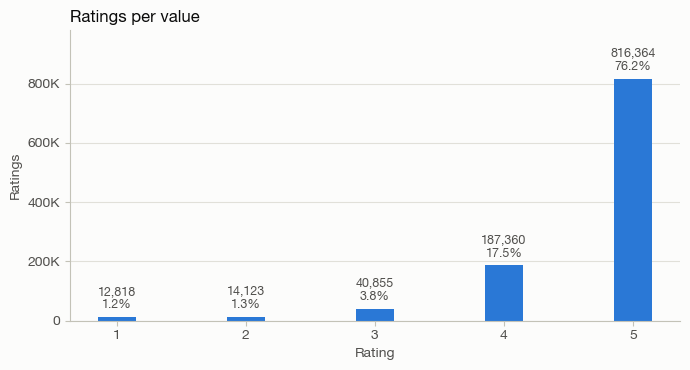

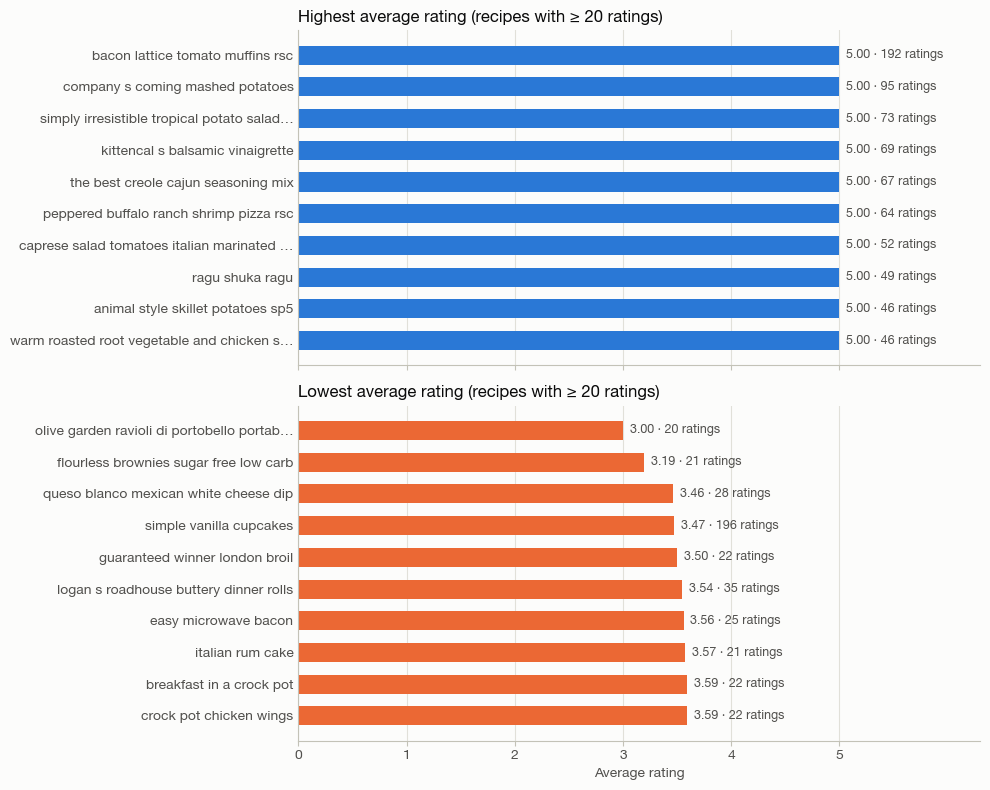

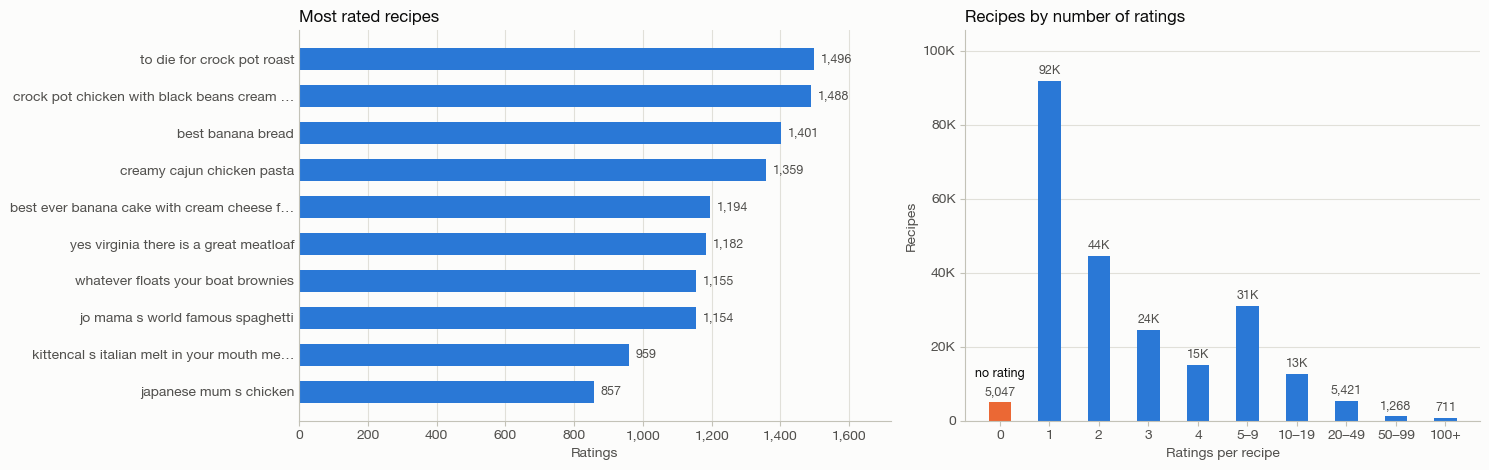

5,047 of 231,637 recipes (2.2%) have no rating; 91,698 have exactly one.


,recipe_id,name,rating_count,average_rating
least rated,,,,
0,164100,1 2 3 hash browns pie k,0,NaN
1,471666,1 2 3 swiss meringue buttercream,0,NaN
2,533190,1 minute breakfast sandwich,0,NaN
3,459738,1 point plus hg s faux fried pickles,0,NaN
4,472955,14 day pickles,0,NaN
5,525649,15 bean soup in the instant pot,0,NaN
6,246548,15 minute italian chicken rice with vegetables,0,NaN
7,531148,15 minute shrimp stir fry,0,NaN
8,282812,15 minutes oatmeal rice cooker,0,NaN


In [6]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

MIN_RATINGS_FOR_AVERAGE = 20
TOP_N = 10
SURFACE, INK, INK_2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
BLUE, ORANGE = "#2a78d6", "#eb6834"
VIZ_STYLE = {
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.family": "sans-serif", "font.sans-serif": ["Helvetica Neue", "Arial", "DejaVu Sans"],
    "font.size": 10, "text.color": INK, "axes.labelcolor": INK_2, "axes.titlesize": 12,
    "axes.titleweight": "semibold", "axes.titlelocation": "left", "axes.titlecolor": INK,
    "axes.edgecolor": AXIS, "axes.linewidth": 0.8, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "xtick.color": AXIS, "ytick.color": AXIS, "xtick.labelcolor": INK_2, "ytick.labelcolor": INK_2,
}


def compact(value, _=None):
    return f"{value / 1e6:.1f}M" if value >= 1e6 else f"{value / 1e3:.0f}K" if value >= 1e4 else f"{value:,.0f}"


def short_name(name, width=42):
    name = " ".join(str(name).split())
    return name if len(name) <= width else name[:width - 1] + "…"


def ranked_bars(ax, frame, value, color, label, title):
    """Horizontal bars, first row on top, each labeled at its tip."""
    rows = frame.iloc[::-1]
    ax.barh(range(len(rows)), rows[value], height=0.6, color=color)
    ax.set_yticks(range(len(rows)), [short_name(name) for name in rows["name"]])
    ax.tick_params(axis="y", length=0)
    ax.grid(axis="y", visible=False)
    for y, (_, row) in enumerate(rows.iterrows()):
        ax.annotate(label(row), (row[value], y), xytext=(5, 0), textcoords="offset points",
                    va="center", color=INK_2, fontsize=9)
    ax.set_title(title)


recipe_stats = item_catalog[["recipe_id", "name"]].copy()
recipe_stats["name"] = recipe_stats["name"].map(lambda name: " ".join(str(name).split()))
star_ratings = observed_ratings  # Every row is a 1-5 star rating.
per_recipe = star_ratings.groupby("item_index")["rating"].agg(["size", "mean"]).reindex(range(len(item_catalog)))
recipe_stats["rating_count"] = per_recipe["size"].fillna(0).astype(np.int64).to_numpy()
recipe_stats["average_rating"] = per_recipe["mean"].to_numpy()

# 1. Ratings per class.
class_counts = observed_ratings["rating"].astype(int).value_counts().reindex(
    range(1, NUM_RATING_CLASSES + 1), fill_value=0)
with plt.rc_context(VIZ_STYLE):
    fig, ax = plt.subplots(figsize=(7, 3.8))
    ax.bar(class_counts.index, class_counts, width=0.3, color=BLUE)
    for rating, count in class_counts.items():
        ax.annotate(f"{count:,}\n{count / class_counts.sum():.1%}", (rating, count), xytext=(0, 4),
                    textcoords="offset points", ha="center", va="bottom", color=INK_2, fontsize=9)
    ax.set(xticks=class_counts.index, xlabel="Rating", ylabel="Ratings", title="Ratings per value")
    ax.yaxis.set_major_formatter(FuncFormatter(compact))
    ax.grid(axis="x", visible=False)
    ax.margins(y=0.2)
    fig.tight_layout()
    plt.show()

# 2. Highest and lowest average rating among recipes with enough ratings.
rated_enough = recipe_stats[recipe_stats["rating_count"] >= MIN_RATINGS_FOR_AVERAGE]
best_rated = rated_enough.sort_values(["average_rating", "rating_count"], ascending=[False, False]).head(TOP_N)
worst_rated = rated_enough.sort_values(["average_rating", "rating_count"], ascending=[True, False]).head(TOP_N)
average_label = lambda row: f"{row.average_rating:.2f} · {row.rating_count:,} ratings"
with plt.rc_context(VIZ_STYLE):
    fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    ranked_bars(axes[0], best_rated, "average_rating", BLUE, average_label,
                f"Highest average rating (recipes with ≥ {MIN_RATINGS_FOR_AVERAGE} ratings)")
    ranked_bars(axes[1], worst_rated, "average_rating", ORANGE, average_label,
                f"Lowest average rating (recipes with ≥ {MIN_RATINGS_FOR_AVERAGE} ratings)")
    axes[1].set(xlim=(0, 6.3), xticks=range(6), xlabel="Average rating")
    fig.tight_layout()
    plt.show()

# 3. Most rated recipes, and recipes by number of ratings (0 = without a rating).
most_rated = recipe_stats.nlargest(TOP_N, "rating_count")
bucket_labels = ["0", "1", "2", "3", "4", "5–9", "10–19", "20–49", "50–99", "100+"]
buckets = pd.cut(recipe_stats["rating_count"], [0, 1, 2, 3, 4, 5, 10, 20, 50, 100, np.inf],
                 right=False, labels=bucket_labels).value_counts().reindex(bucket_labels)
with plt.rc_context(VIZ_STYLE):
    fig, (left, right) = plt.subplots(1, 2, figsize=(15, 4.8), gridspec_kw={"width_ratios": [1.15, 1]})
    ranked_bars(left, most_rated, "rating_count", BLUE, lambda row: f"{row.rating_count:,}", "Most rated recipes")
    left.set(xlim=(0, most_rated["rating_count"].max() * 1.15), xlabel="Ratings")
    left.xaxis.set_major_formatter(FuncFormatter(compact))
    right.bar(bucket_labels, buckets, width=0.45, color=[ORANGE] + [BLUE] * (len(bucket_labels) - 1))
    for x, count in enumerate(buckets):
        right.annotate(compact(count), (x, count), xytext=(0, 3), textcoords="offset points",
                       ha="center", va="bottom", color=INK_2, fontsize=9)
    right.annotate("no rating", (0, buckets.iloc[0]), xytext=(0, 16), textcoords="offset points",
                   ha="center", va="bottom", color=INK, fontsize=9)
    right.set(title="Recipes by number of ratings", xlabel="Ratings per recipe", ylabel="Recipes")
    right.yaxis.set_major_formatter(FuncFormatter(compact))
    right.grid(axis="x", visible=False)
    right.margins(y=0.15)
    fig.tight_layout()
    plt.show()

unrated = recipe_stats["rating_count"].eq(0)
print(f"{unrated.sum():,} of {len(recipe_stats):,} recipes ({unrated.mean():.1%}) have no rating; "
      f"{recipe_stats['rating_count'].eq(1).sum():,} have exactly one.")
least_rated = recipe_stats.sort_values(["rating_count", "name"], kind="stable").head(TOP_N)
display(least_rated.reset_index(drop=True).rename_axis("least rated"))

**Rating shares before and after rating-5 thinning**

Thinning changes training targets only, so this compares the training split before thinning
(`train_ratings`) with the targets (`train_targets`). Validation and user histories keep every
rating. Thinning is off (`THIN_FIVE_STAR_TARGETS = False`): every 3–5★ rating is a positive, and
the in-batch softmax's logQ correction already handles popularity, so both bars match. The plot
reuses the style from the overview cell above.

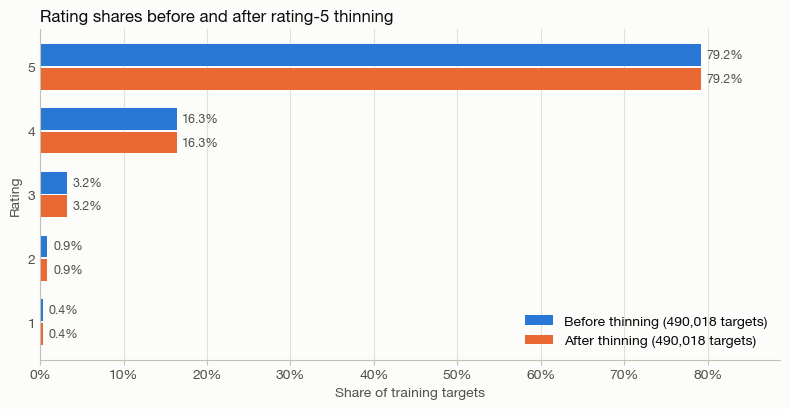

,before_count,before_percent,after_count,after_percent,change_points
rating,,,,,
1,1894,0.39,1894,0.39,0.0
2,4295,0.88,4295,0.88,0.0
3,15811,3.23,15811,3.23,0.0
4,80085,16.34,80085,16.34,0.0
5,387933,79.17,387933,79.17,0.0


In [7]:
from matplotlib.ticker import PercentFormatter

counts = {when: frame["rating"].astype(int).value_counts().reindex(rating_levels, fill_value=0)
          for when, frame in [("before", train_ratings), ("after", train_targets)]}
thinning_shares = pd.DataFrame({
    "before_count": counts["before"], "before_percent": 100 * counts["before"] / counts["before"].sum(),
    "after_count": counts["after"], "after_percent": 100 * counts["after"] / counts["after"].sum(),
})
thinning_shares["change_points"] = thinning_shares["after_percent"] - thinning_shares["before_percent"]

bar_height, bar_gap = 0.34, 0.03
with plt.rc_context(VIZ_STYLE):
    fig, ax = plt.subplots(figsize=(8, 4.2))
    for when, color, direction in [("before", BLUE, 1), ("after", ORANGE, -1)]:
        positions = rating_levels + direction * (bar_height + bar_gap) / 2
        shares = thinning_shares[f"{when}_percent"]
        ax.barh(positions, shares, height=bar_height, color=color,
                label=f"{when.capitalize()} thinning ({counts[when].sum():,} targets)")
        for position, share in zip(positions, shares):
            ax.annotate(f"{share:.1f}%", (share, position), xytext=(4, 0), textcoords="offset points",
                        va="center", color=INK_2, fontsize=9)
    ax.set(yticks=rating_levels, xlabel="Share of training targets", ylabel="Rating",
           xlim=(0, thinning_shares[["before_percent", "after_percent"]].to_numpy().max() * 1.12),
           title="Rating shares before and after rating-5 thinning")
    ax.xaxis.set_major_formatter(PercentFormatter(100))
    ax.tick_params(axis="y", length=0)
    ax.grid(axis="y", visible=False)
    ax.legend(frameon=False, loc="lower right")
    fig.tight_layout()
    plt.show()
display(thinning_shares.round(2))

**Ratings per user**

How much history each user has: every 1–5★ rating, then after the user/recipe filter, the
per-user split, and (only with `THIN_FIVE_STAR_TARGETS`) rating-5 thinning. The user tower learns
a user's taste only from these ratings. The plot uses all observed ratings.

,users,ratings,mean,median,p75,p90,p99,max,share_with_1,share_with_5_or_fewer
observed,196098.0,1071520.0,5.464,1.0,2.0,5.0,68.00,7665.0,0.716,0.904
core,14424.0,518866.0,35.972,13.0,26.0,66.0,427.77,2763.0,0.000,0.000
train_history,14424.0,490018.0,33.972,11.0,24.0,64.0,425.77,2761.0,0.000,0.223
train_targets,14424.0,490018.0,33.972,11.0,24.0,64.0,425.77,2761.0,0.000,0.223
validation,14424.0,28848.0,2.000,2.0,2.0,2.0,2.00,2.0,0.000,1.000


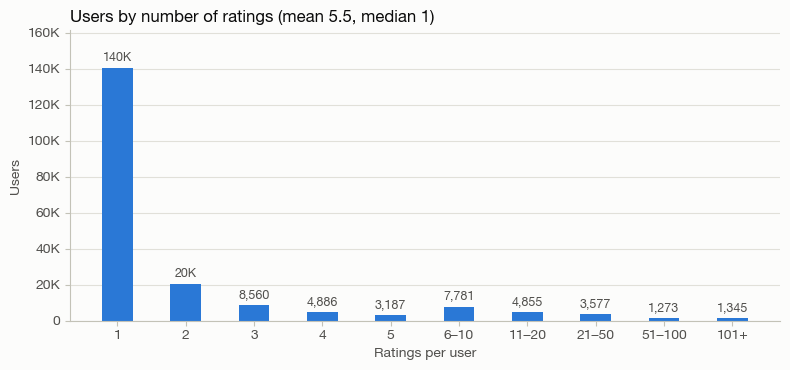

In [8]:
per_user = {name: frame.groupby("user_id").size()
            for name, frame in [("observed", observed_ratings), ("core", core_ratings),
                                ("train_history", train_ratings),
                                ("train_targets", train_targets), ("validation", validation_ratings)]}
user_summary = pd.DataFrame({
    name: {"users": len(counts), "ratings": int(counts.sum()), "mean": counts.mean(), "median": counts.median(),
           "p75": counts.quantile(0.75), "p90": counts.quantile(0.90), "p99": counts.quantile(0.99),
           "max": counts.max(), "share_with_1": (counts == 1).mean(), "share_with_5_or_fewer": (counts <= 5).mean()}
    for name, counts in per_user.items()
}).T
display(user_summary.round(3))

user_bucket_labels = ["1", "2", "3", "4", "5", "6–10", "11–20", "21–50", "51–100", "101+"]
user_buckets = pd.cut(per_user["observed"], [0, 1, 2, 3, 4, 5, 10, 20, 50, 100, np.inf],
                      labels=user_bucket_labels).value_counts().reindex(user_bucket_labels)
with plt.rc_context(VIZ_STYLE):
    fig, ax = plt.subplots(figsize=(8, 3.8))
    ax.bar(user_bucket_labels, user_buckets, width=0.45, color=BLUE)
    for x, count in enumerate(user_buckets):
        ax.annotate(compact(count), (x, count), xytext=(0, 3), textcoords="offset points",
                    ha="center", va="bottom", color=INK_2, fontsize=9)
    ax.set(title=f"Users by number of ratings (mean {per_user['observed'].mean():.1f}, "
                 f"median {per_user['observed'].median():.0f})",
           xlabel="Ratings per user", ylabel="Users")
    ax.yaxis.set_major_formatter(FuncFormatter(compact))
    ax.grid(axis="x", visible=False)
    ax.margins(y=0.15)
    fig.tight_layout()
    plt.show()

**Recipe prices and nutrient values**

One value per recipe in `item_catalog`, rated or not, before the item tower's `log1p`, clipping,
and scaling:

- **Nutrients:** the seven nutrition columns as they come from the input CSV. Every column is
  right-skewed, so the x-axes are logarithmic. A log axis can't show zeros, so each title gives
  their share, and the line marks the median. The CSV's values are Food.com's nutrition values
  times each nutrient's daily value (calories × 2000, sugar × 50, …), so compare shapes rather
  than magnitudes.
- **Prices:** the known ingredient prices summed per recipe, and how many of its ingredients
  have no price. Each missing price adds ±$2 of uncertainty (`MISSING_PRICE_ERROR_DOLLARS`),
  not an imputed cost.

The table gives each column's share of missing and zero values and its 1st, 50th, and 99th
percentiles.

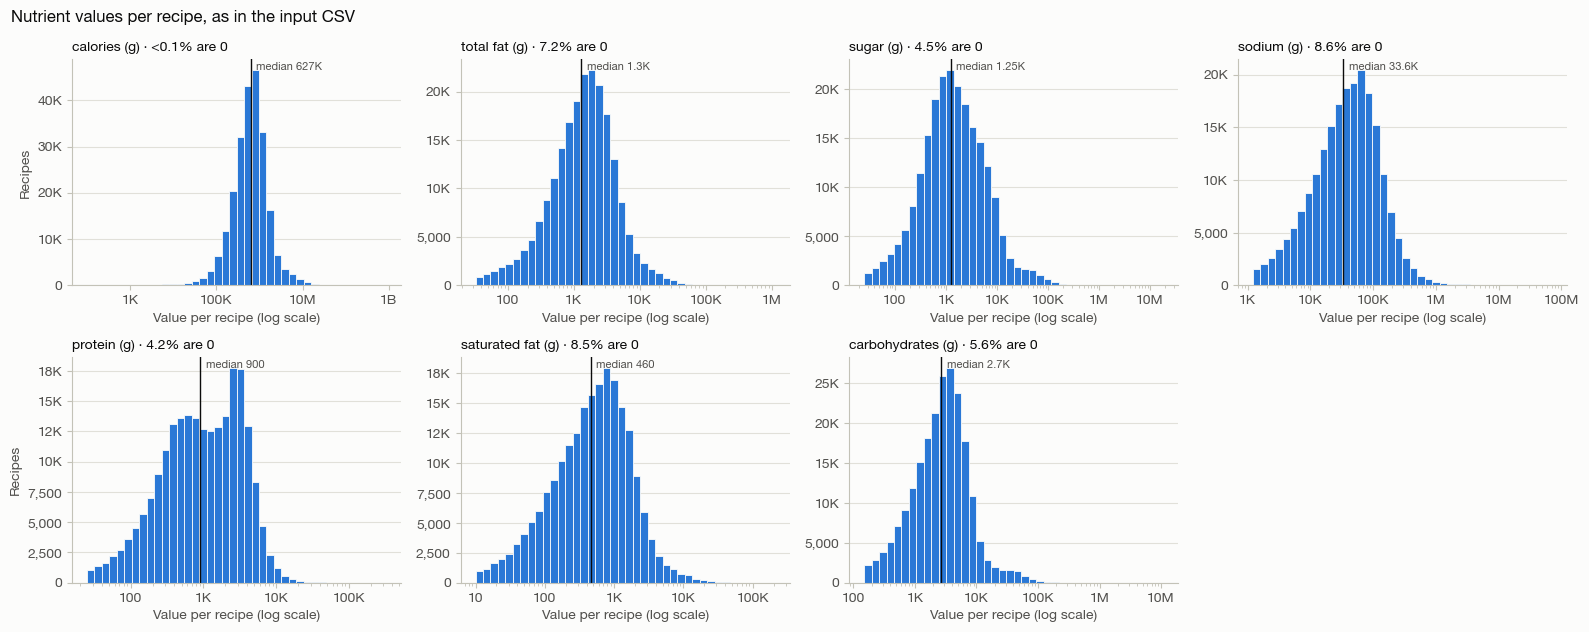

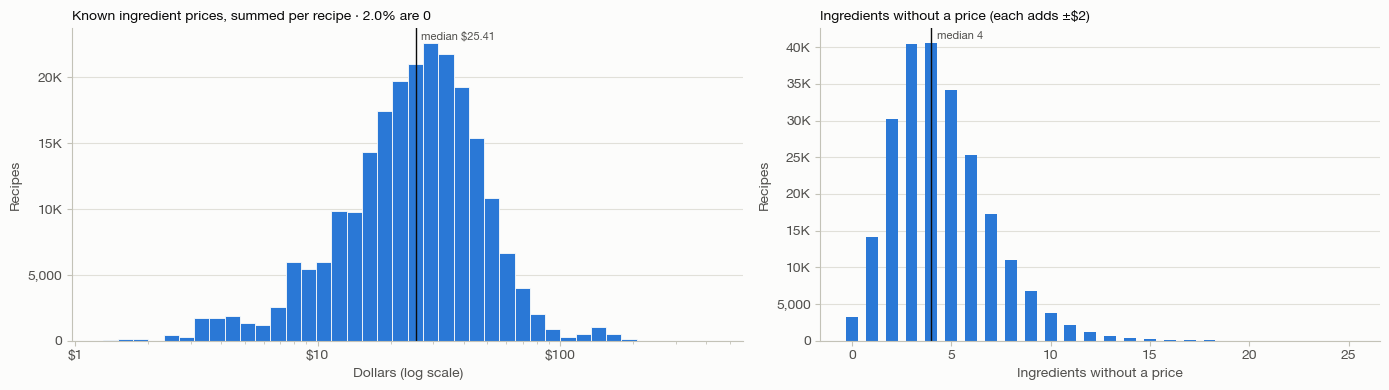

,count,missing_share,zero_share,min,1%,50%,99%,max
calories (g),231637.0,0.0,0.000,0.0,36800.0,626800.00,7033912.000,8.687204e+08
total fat (g),231637.0,0.0,0.072,0.0,0.0,1300.00,19630.000,1.116895e+06
sugar (g),231637.0,0.0,0.045,0.0,0.0,1250.00,57082.000,1.813645e+07
sodium (g),231637.0,0.0,0.086,0.0,0.0,33600.00,525600.000,7.041120e+07
protein (g),231637.0,0.0,0.042,0.0,0.0,900.00,9400.000,3.276000e+05
saturated fat (g),231637.0,0.0,0.085,0.0,0.0,460.00,8080.000,2.079000e+05
carbohydrates (g),231637.0,0.0,0.056,0.0,0.0,2700.00,46200.000,1.082940e+07
price_total_known,231637.0,0.0,0.020,0.0,0.0,25.41,104.968,4.259900e+02
price_missing_count,231637.0,0.0,0.014,0.0,0.0,4.00,12.000,2.500000e+01
price_lower,231637.0,0.0,0.102,0.0,0.0,16.66,94.315,4.119900e+02


In [9]:
DISTRIBUTION_BINS = 40


def short_number(value, _=None):
    """1.2K, 3.4M, 5.6B, or the value itself, to 3 significant digits."""
    for limit, suffix in ((1e9, "B"), (1e6, "M"), (1e3, "K")):
        if abs(value) >= limit:
            return f"{value / limit:.3g}{suffix}"
    return f"{value:.3g}"


def log_histogram(ax, values, title, xlabel, value_format=short_number):
    """Histogram of the positive values on a log x-axis with the median marked; zeros are counted in the title.

    The values come in whole steps (a nutrient in one daily-value percent, a price in cents), so
    each is spread uniformly across its step before binning; narrow log bins would otherwise hold
    one or two steps in turn and show combs that aren't in the data.
    """
    values = np.asarray(values, dtype=np.float64)
    values = values[np.isfinite(values)]
    positive = values[values > 0]
    distinct = np.unique(positive)
    step = np.diff(distinct).min() if len(distinct) > 1 else 0.0
    spread = positive + np.random.default_rng(0).uniform(-step / 2, step / 2, len(positive))
    spread = spread[spread > 0]
    ax.hist(spread, bins=np.geomspace(spread.min(), spread.max(), DISTRIBUTION_BINS + 1),
            color=BLUE, edgecolor=SURFACE, linewidth=0.6)
    ax.set_xscale("log")
    ax.xaxis.set_major_formatter(FuncFormatter(short_number))
    median = np.median(values)
    if median > 0:
        ax.axvline(median, color=INK, linewidth=1)
        ax.annotate(f"median {value_format(median)}", (median, 1), xycoords=("data", "axes fraction"),
                    xytext=(4, -2), textcoords="offset points", va="top", color=INK_2, fontsize=8)
    zeros = np.mean(values == 0)
    zero_text = "" if not zeros else f" · {zeros:.1%} are 0" if zeros >= 0.001 else " · <0.1% are 0"
    ax.set_title(title + zero_text, fontsize=10)
    ax.set(xlabel=xlabel, ylabel="Recipes")
    ax.yaxis.set_major_formatter(FuncFormatter(compact))
    ax.grid(axis="x", visible=False)


distribution_columns = [*NUTRITION_COLUMNS, "price_total_known", "price_missing_count", "price_lower", "price_upper"]
distribution_values = item_catalog[distribution_columns].apply(pd.to_numeric, errors="coerce")

# 1. Nutrients: one panel per column.
with plt.rc_context(VIZ_STYLE):
    fig, axes = plt.subplots(2, 4, figsize=(16, 6.4))
    for ax, column in zip(axes.flat, NUTRITION_COLUMNS):
        log_histogram(ax, distribution_values[column], column, "Value per recipe (log scale)")
    for ax in axes[:, 1:].flat:
        ax.set_ylabel("")
    axes.flat[-1].axis("off")
    fig.suptitle("Nutrient values per recipe, as in the input CSV", x=0.01, ha="left",
                 fontsize=12, fontweight="semibold")
    fig.tight_layout()
    plt.show()

# 2. Prices: the summed known prices, and how many ingredients have no price.
missing_prices = distribution_values["price_missing_count"].astype(int).value_counts().sort_index()
with plt.rc_context(VIZ_STYLE):
    fig, (left, right) = plt.subplots(1, 2, figsize=(14, 4), gridspec_kw={"width_ratios": [1.2, 1]})
    log_histogram(left, distribution_values["price_total_known"], "Known ingredient prices, summed per recipe",
                  "Dollars (log scale)", value_format=lambda value: f"${value:,.2f}")
    left.xaxis.set_major_formatter(FuncFormatter(lambda value, _: f"${value:,.0f}" if value >= 1 else f"${value:.2g}"))
    right.bar(missing_prices.index, missing_prices, width=0.6, color=BLUE)
    median_missing = distribution_values["price_missing_count"].median()
    right.axvline(median_missing, color=INK, linewidth=1)
    right.annotate(f"median {median_missing:g}", (median_missing, 1), xycoords=("data", "axes fraction"),
                   xytext=(4, -2), textcoords="offset points", va="top", color=INK_2, fontsize=8)
    right.set_title(f"Ingredients without a price (each adds ±${MISSING_PRICE_ERROR_DOLLARS:g})", fontsize=10)
    right.set(xlabel="Ingredients without a price", ylabel="Recipes")
    right.yaxis.set_major_formatter(FuncFormatter(compact))
    right.grid(axis="x", visible=False)
    fig.tight_layout()
    plt.show()

distribution_summary = distribution_values.describe(percentiles=[0.01, 0.5, 0.99]).T.drop(columns=["mean", "std"])
distribution_summary.insert(1, "missing_share", distribution_values.isna().mean())
distribution_summary.insert(2, "zero_share", distribution_values.eq(0).mean())
display(distribution_summary.round(3))

**Recipe features: the item tower's inputs**

Following `two-tower-embeddings.md`, every feature group gets its own projection to `PART_DIM`
inside the item tower, so a wide group (the 128-d text embedding) can't swamp a narrow one (four
price columns):

| Group | Built here | In the item tower |
|---|---|---|
| **ingredients** | the recipe's products (its raw ingredients when it has none): lowercased, lemmatized, singularized ("Green Onions" → "green onion"), deduplicated | frozen `TERM_MODEL` vector per ingredient → mean per recipe (`EmbeddingBag`) → learned linear 384 → 32 |
| **adjectives** | adjective terms, lowercased and lemmatized ("softer" → "soft") | frozen vectors → mean → linear |
| **verbs** | verb terms, lowercased and lemmatized to the base form ("chopped" → "chop") | frozen vectors → mean → linear |
| **tags** | Food.com tags from `RAW_recipes.csv` ("60-minutes-or-less" → "60 minutes or less"), without the category headers in `GENERIC_TAGS` ("preparation", "course", …) | frozen vectors → mean → linear |
| **nutrition** | the seven nutrient columns: `log1p` → clip at the `CLIP_QUANTILE` quantile → standardize on training recipes; missing flags; one-hot of a k-means nutrition cluster | linear → 32 |
| **price** | known total and missing-price uncertainty (`log1p`), missing share, all-missing flag → clip → standardize | linear → 32 |
| **time** | `minutes` and `n_steps` from `RAW_recipes.csv`: `log1p` → clip → standardize; missing flags | linear → 32 |
| **text** | "name. description" through the frozen `BERT_MODEL` (first `TEXT_MAX_LENGTH` tokens), SVD to `TEXT_EMBEDDING_DIM` | linear → 32 |
| **recipe ID** | a row for each recipe with ≥ `MIN_ITEM_RATINGS_FOR_ID` training positives, row 0 (zeros) for the rest | embedding → 32, with ID dropout |

Each distinct term is embedded once and cached in `output/two_tower_cache`, and so is the text
embedding (about 20 minutes on Apple silicon the first time, a few minutes on a CUDA GPU).
Scalers, clip medians, and the nutrition k-means are fit on training recipes and applied to
every recipe; raw values stay in `item_catalog` for display and rule filters. Content
preprocessing never reads user IDs or dates. Review text is not used.

References: [all-MiniLM-L6-v2](https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2),
[BERT](https://huggingface.co/docs/transformers/model_doc/bert), and
[WordNet lemmatizer](https://www.nltk.org/api/nltk.stem.wordnet.html).

In [10]:
# Scalers and the nutrition k-means see training recipes only; every recipe is transformed.
train_items = np.unique(train_ratings["item_index"].to_numpy())
numeric_groups, nutrition_cluster_means, numeric_preprocessing = build_numeric_features(
    item_catalog, train_items, n_clusters=NUTRITION_CLUSTERS, seed=RANDOM_STATE, clip_quantile=CLIP_QUANTILE
)
recipe_metadata = load_recipe_metadata(item_catalog, RAW_RECIPES_PATH)
item_catalog["tag_terms"] = recipe_tags(recipe_metadata)
time_features, extra_preprocessing = build_recipe_extras(recipe_metadata, train_items, clip_quantile=CLIP_QUANTILE)
text_features, text_preprocessing = encode_recipe_texts(
    recipe_texts(item_catalog, recipe_metadata), CACHE_DIR, device, model_name=BERT_MODEL,
    revision=BERT_REVISION, batch_size=TEXT_BATCH_SIZE, max_length=TEXT_MAX_LENGTH,
    dim=TEXT_EMBEDDING_DIM, seed=RANDOM_STATE
)
item_features, feature_groups = stack_feature_groups({**numeric_groups, "time": time_features, "text": text_features})
del numeric_groups, time_features, text_features
assert np.isfinite(item_features).all()
# Frozen pretrained vector per distinct normalized term; each recipe keeps its term ids per field.
term_vocabulary = build_term_vocabulary(item_catalog)
term_vectors = encode_terms(term_vocabulary, CACHE_DIR, device, model_name=TERM_MODEL, revision=TERM_REVISION,
                            batch_size=TERM_BATCH_SIZE)
item_terms = {field: term_id_matrix(item_catalog[column], term_vocabulary) for field, (column, _) in TERM_FIELDS.items()}
print(f"Item feature matrix: {item_features.shape}; {item_features.nbytes / 2**20:.1f} MiB; groups: "
      + ", ".join(f"{name} {end - start}" for name, start, end in feature_groups))
print(f"Terms: {len(term_vocabulary):,} distinct normalized terms, {term_vectors.shape[1]}-d frozen {TERM_MODEL} vectors")
display(pd.DataFrame({field: {"recipes with a term": f"{(matrix > 0).any(axis=1).mean():.1%}",
                              "distinct terms": len(np.unique(matrix[matrix > 0])),
                              "median terms per recipe": float(np.median((matrix > 0).sum(axis=1))),
                              "most terms": matrix.shape[1]} for field, matrix in item_terms.items()}))
display(item_catalog[["name", "ingredient_terms", "adj_terms", "verb_terms", "tag_terms"]].head())
display(nutrition_cluster_means)
display(item_catalog[["recipe_id", "name", "nutrition_cluster", "price_total_known",
                      "price_missing_count", "price_error_dollars", "price_lower", "price_upper"]].head())

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Item feature matrix: (231637, 182); 160.8 MiB; groups: nutrition 46, price 4, time 4, text 128
Terms: 9,904 distinct normalized terms, 384-d frozen sentence-transformers/all-MiniLM-L6-v2 vectors


,ingredients,adjectives,verbs,tags
recipes with a term,100.0%,75.6%,44.6%,100.0%
distinct terms,8601,837,403,540
median terms per recipe,8.0,1.0,0.0,11.0
most terms,41,12,8,63


,name,ingredient_terms,adj_terms,verb_terms,tag_terms
0,arriba baked winter squash mexican style,"[winter squash, mexican seasoning, mixed spice...",[],[],"[60 minutes or less, north american, side dish..."
1,a bit different breakfast pizza,"[pizza, sausage patty, egg, milk, salt pepper,...",[],[prepare],"[30 minutes or less, north american, breakfast..."
2,all in the kitchen chili,"[beef, onion, tomato, tomato paste, soup, rote...","[yellow, tomato]","[grind, dice]","[main dish, chili, crock pot slow cooker, 4 ho..."
3,alouette potatoes,"[spreadable, cheese, garlic, herb, new potato,...","[red, yellow]",[],"[60 minutes or less, side dishes, eggs dairy, ..."
4,amish tomato ketchup for canning,"[tomato juice, apple cider vinegar, sugar, sal...",[],[],"[weeknight, north american, canning, condiment..."


,calories (g),total fat (g),sugar (g),sodium (g),protein (g),saturated fat (g),carbohydrates (g)
nutrition_cluster,,,,,,,
0,9.360319e+05,3210.706958,426.201142,73162.979554,2974.311827,1327.555812,1138.443754
1,5.774071e+05,78.305882,8532.352941,91862.964706,539.176471,0.000000,6277.694118
2,2.821689e+05,832.135192,462.136298,31363.823432,439.346167,286.728620,1068.503153
3,1.075638e+06,2194.053560,3135.031364,125950.616944,3190.694148,708.571035,5123.885021
4,6.301396e+05,2278.761273,133.379259,45808.617234,2328.807615,852.790581,0.000000
5,1.455526e+05,624.570175,84.298246,25617.684211,183.052632,214.449123,0.000000
6,3.085232e+05,0.671391,5178.909440,214.460725,0.000000,0.225799,2735.815518
7,4.752168e+05,1101.242513,2929.453963,0.000000,390.945814,271.984956,2986.335144
8,3.269474e+06,9309.086188,4191.869478,276677.848396,7016.834599,3437.073322,12680.359634


,recipe_id,name,nutrition_cluster,price_total_known,price_missing_count,price_error_dollars,price_lower,price_upper
0,137739,arriba baked winter squash mexican style,9,38.83,3,6.0,32.83,44.83
1,31490,a bit different breakfast pizza,25,25.95,2,4.0,21.95,29.95
2,112140,all in the kitchen chili,29,58.35,5,10.0,48.35,68.35
3,59389,alouette potatoes,17,32.77,6,12.0,20.77,44.77
4,44061,amish tomato ketchup for canning,1,30.35,4,8.0,22.35,38.35


In [11]:
# Training rows are liked ratings (3-5 stars); every training rating (1-5) is history.
user_lookup = build_user_lookup(train_ratings)  # The training users (the reranker's user vocabulary).
train_positive_targets = positive_rows(train_targets)
validation_positive_targets = positive_rows(validation_ratings)
dataset_options = dict(max_history=MAX_HISTORY, half_life_days=RECENCY_HALF_LIFE_DAYS)
train_dataset = HistoryDataset(train_positive_targets, train_ratings, training=True, **dataset_options)
# Validation masks also see the held-out ratings, so another held-out liked recipe is never a negative.
validation_dataset = HistoryDataset(validation_positive_targets, train_ratings, training=False,
                                    extra_interactions=validation_ratings, **dataset_options)
item_id_rows, num_item_ids = build_item_id_rows(train_positive_targets["item_index"], len(item_catalog),
                                                MIN_ITEM_RATINGS_FOR_ID)
core_items = np.zeros(len(item_catalog), dtype=bool)  # Recall@K ranks only recipes that passed the filter.
core_items[core_ratings["item_index"].to_numpy()] = True
epoch_rows = len(train_dataset.resample(MAX_ROWS_PER_USER, RANDOM_STATE))
recall_sample = RecallAtK(train_ratings, validation_positive_targets, len(item_catalog), ks=RECALL_KS,
                          max_history=MAX_HISTORY, sample_users=RECALL_SAMPLE_USERS, seed=RANDOM_STATE,
                          candidate_items=core_items)
print(f"{len(user_lookup):,} training users")
print(f"Training rows (ratings ≥ {POSITIVE_MIN_RATING}): {len(train_dataset.targets):,} ({epoch_rows:,} per epoch "
      f"with at most {MAX_ROWS_PER_USER} per user); validation rows: {len(validation_dataset):,}")
print(f"{num_item_ids:,} of {len(item_catalog):,} recipes have at least {MIN_ITEM_RATINGS_FOR_ID} training "
      "positives and get their own ID embedding; the rest use content features only")
print(f"Recall@K after each epoch: {len(recall_sample.users):,} sampled validation users, "
      f"ranking {core_items.sum():,} recipes")

14,424 training users
Training rows (ratings ≥ 3): 483,829 (252,920 per epoch with at most 50 per user); validation rows: 28,199
37,017 of 231,637 recipes have at least 5 training positives and get their own ID embedding; the rest use content features only
Recall@K after each epoch: 10,000 sampled validation users, ranking 39,234 recipes


**From ratings to one training batch**

1. **Rows:** every training rating of 3★ or more is a row; 1–2★ ratings only appear in histories.
2. **Epoch:** at most `MAX_ROWS_PER_USER` rows per user, resampled every epoch.
3. **User tower input:** the row's user's earlier ratings, target excluded. The history table
   shows the most recent ratings of the example user's row with the longest history, and each
   recipe's weight in the pooled vector (0 for a 1–2★ recipe; the GRU still reads it).
4. **Logits:** every user against every positive in the batch, `[B × B]`. Row `i`'s label is
   column `i` (P) and the other columns are in-batch negatives (N); a column holding another
   recipe the row's user liked is masked ("mask: liked").

The cell shows these steps on real rows. Its batch puts three rows of one user together, so
their recipes mask each other.

In [12]:
# 1. Ratings by level for a few users who liked (3-5 stars) and disliked (1-2 stars) recipes.
level_counts = (train_ratings.groupby(["user_id", "level"]).size().unstack(fill_value=0)
                .reindex(columns=LEVEL_NAMES, fill_value=0))
example_users = level_counts[(level_counts["negative"] > 0) & (level_counts["positive"] >= 3)].index[:5]
example_split = (train_ratings[train_ratings.user_id.isin(example_users)]
                 .assign(recipe=lambda frame: frame.item_index.map(item_catalog["name"].str.slice(0, 30)))
                 .groupby(["user_id", "level"])["recipe"].apply(list).unstack().reindex(columns=LEVEL_NAMES))
display(example_split)

# 2. A real batch from HistoryDataset.collate: the latest three rows of one user plus five other rows.
example_rng = np.random.default_rng(RANDOM_STATE)
active_users = train_dataset.targets["user_id"].to_numpy()[train_dataset.active]
own_positions = np.flatnonzero(active_users == example_users[0])[-3:]
other_positions = example_rng.choice(np.flatnonzero(active_users != example_users[0]), 8 - len(own_positions),
                                     replace=False)
example_batch = train_dataset.collate([train_dataset[int(position)]
                                       for position in np.concatenate([own_positions, other_positions])])
example_row_users = train_dataset.targets["user_id"].to_numpy()[example_batch["row"].numpy()]
print("I =", example_batch["item_index"].tolist())

# 3. The history of the user's row with the most history, as the user tower sees it (most recent last).
shown_row = int(example_batch["history_mask"][:len(own_positions)].sum(dim=1).argmax())
shown_mask = example_batch["history_mask"][shown_row]
shown_weights = history_pool_weights(example_batch["history_ratings"][shown_row:shown_row + 1],
                                     example_batch["history_age_days"][shown_row:shown_row + 1],
                                     example_batch["history_mask"][shown_row:shown_row + 1], RECENCY_HALF_LIFE_DAYS)[0]
shown_history = pd.DataFrame({
    "recipe": item_catalog["name"].to_numpy()[example_batch["history_items"][shown_row][shown_mask].numpy()],
    "rating": example_batch["history_ratings"][shown_row][shown_mask].numpy() + 1,
    "age_days": example_batch["history_age_days"][shown_row][shown_mask].numpy().round(0),
    "pool_weight": shown_weights[shown_mask].numpy().round(3),
})
print(f"Row {shown_row}'s history: {len(shown_history)} earlier ratings; the pooled vector uses the "
      f"{(shown_history['pool_weight'] > 0).sum()} liked ones (last 10 shown)")
display(shown_history.tail(10))

# 4. The [B, B] logits grid: P on the diagonal, in-batch negatives, and masked liked recipes.
example_roles = train_dataset.batch_roles(example_batch["row"].numpy(), example_batch["item_index"].numpy())
display(pd.DataFrame(np.array(BATCH_ROLES, dtype=object)[example_roles],
                     index=[f"row {row}: user {user}" for row, user in enumerate(example_row_users)],
                     columns=[f"I:{item}" for item in example_batch["item_index"].tolist()]))

level,negative,positive
user_id,,
100149,"[crock pot garlic brown sugar c, creamy garlic...","[baked chicken breasts, blt bites, sour cream ..."
1002265,"[tons of blueberry coffee cake, frosted brown...","[waldorf astoria red velvet cak, aunt woofie s..."
1004779,"[zesty low fat chicken breasts, kittencal s mu...","[jumbo strawberry and chocolate, strawberry sw..."
1005276,[quick n easy quiche crust],"[crock pot chili pork chops , uncle bill s ..."
1005886,"[elvis favorite sweet potato c, herbed top ro...","[pan fried onion dip, easy cole slaw, another ..."


I = [12579, 67142, 53544, 23243, 208676, 2288, 88011, 20685]
Row 2's history: 22 earlier ratings; the pooled vector uses the 20 liked ones (last 10 shown)


,recipe,rating,age_days,pool_weight
12,kahlua pumpkin pie,5,105.0,0.094
13,maple krispie cookies,5,105.0,0.094
14,peaches cream pie,5,105.0,0.094
15,steak balmoral,5,103.0,0.095
16,the bombdiggity chicken,3,103.0,0.032
17,to die for crock pot roast,5,103.0,0.095
18,kids love s mores pops,5,93.0,0.098
19,bacon mushroom chicken,5,92.0,0.099
20,crunchy chicken casserole,5,56.0,0.113
21,creamy garlic chicken,2,19.0,0.000


,I:12579,I:67142,I:53544,I:23243,I:208676,I:2288,I:88011,I:20685
row 0: user 100149,P,mask: liked,mask: liked,N,N,N,N,N
row 1: user 100149,mask: liked,P,mask: liked,N,N,N,N,N
row 2: user 100149,mask: liked,mask: liked,P,N,N,N,N,N
row 3: user 587527,N,N,N,P,N,N,N,N
row 4: user 294700,N,N,N,N,P,N,N,N
row 5: user 464185,N,N,N,N,N,P,N,N
row 6: user 12657,N,N,N,N,N,N,P,N
row 7: user 29166,N,N,N,N,N,N,N,P


**What each training batch holds**

One epoch as `train_two_tower` builds it: at most `MAX_ROWS_PER_USER` rows per user, shuffled,
full batches of `BATCH_SIZE` (the last partial batch is dropped). For each batch: how many rows
are 3★, 4★, and 5★ ratings (every row is a positive), and, for the first 200 batches, how many of
its `B × B` in-batch softmax logits are masked as another recipe the row's user liked.

493 batches of 512 rows (504 rows dropped as the last partial batch); in-batch softmax logits per batch: 512 x 512


,rows,rated_3,rated_4,rated_5,masked_liked
mean,512.0,19.8,83.9,408.3,2272.5
std,0.0,4.5,8.6,9.2,243.1
min,512.0,8.0,63.0,371.0,1673.0
50%,512.0,20.0,84.0,408.0,2266.0
max,512.0,33.0,122.0,433.0,2960.0


,rows,rated_3,rated_4,rated_5,masked_liked
batch,,,,,
0,512,19,122,371,2497.0
1,512,25,75,412,2412.0
2,512,24,79,409,2283.0
3,512,25,85,402,1767.0
4,512,15,89,408,2284.0
5,512,20,89,403,2309.0
6,512,17,85,410,2727.0
7,512,33,85,394,2416.0
8,512,16,80,416,2278.0


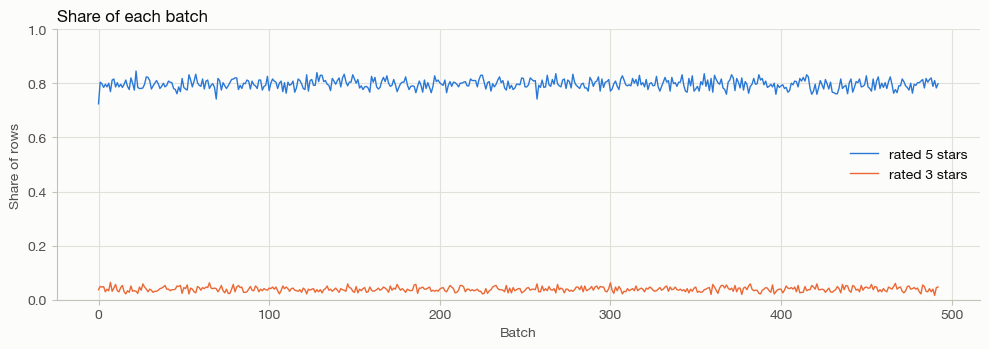

In [13]:
# Labels only, so a full epoch takes seconds instead of building every row's history.
train_dataset.resample(MAX_ROWS_PER_USER, RANDOM_STATE)
draw_rng = np.random.default_rng(RANDOM_STATE)
epoch_positions = train_dataset.active[draw_rng.permutation(len(train_dataset))]
epoch_ratings = train_dataset.targets["rating"].to_numpy()[epoch_positions].astype(int)
epoch_positives = train_dataset.targets["item_index"].to_numpy()[epoch_positions]
batch_count = len(epoch_positions) // BATCH_SIZE  # drop_last, like training
batch_ids = np.arange(batch_count * BATCH_SIZE) // BATCH_SIZE
used = slice(0, batch_count * BATCH_SIZE)
batch_classes = pd.DataFrame({
    "rows": pd.Series(batch_ids).value_counts().sort_index(),
    **{f"rated_{r}": pd.Series(batch_ids[epoch_ratings[used] == r]).value_counts()
       for r in range(POSITIVE_MIN_RATING, NUM_RATING_CLASSES + 1)},
}).fillna(0).astype(int).rename_axis("batch")
batch_classes["masked_liked"] = pd.Series(
    [int((train_dataset.batch_roles(epoch_positions[rows], epoch_positives[rows]) == ROLE_LIKED).sum())
     for rows in (slice(batch * BATCH_SIZE, (batch + 1) * BATCH_SIZE) for batch in range(min(batch_count, 200)))],
    dtype="float64")
print(f"{batch_count:,} batches of {BATCH_SIZE} rows ({len(epoch_positions) - batch_count * BATCH_SIZE:,} rows "
      f"dropped as the last partial batch); in-batch softmax logits per batch: {BATCH_SIZE} x {BATCH_SIZE}")
display(batch_classes.describe().loc[["mean", "std", "min", "50%", "max"]].round(1))
display(batch_classes.head(10))
with plt.rc_context(VIZ_STYLE):
    fig, ax = plt.subplots(figsize=(10, 3.6))
    shares = batch_classes[["rated_5", "rated_3"]].div(batch_classes["rows"], axis=0)
    ax.plot(shares.index, shares["rated_5"], color=BLUE, linewidth=1, label="rated 5 stars")
    ax.plot(shares.index, shares["rated_3"], color=ORANGE, linewidth=1, label="rated 3 stars")
    ax.set(title="Share of each batch", xlabel="Batch", ylabel="Share of rows", ylim=(0, 1))
    ax.legend(frameon=False, loc="center right")
    fig.tight_layout()
    plt.show()

In [14]:
recommendation_model = TwoTowerModel(
    feature_groups, num_items=len(item_catalog), embedding_dim=EMBEDDING_DIM, part_dim=PART_DIM,
    hidden_dim=HIDDEN_DIM, half_life_days=RECENCY_HALF_LIFE_DAYS, num_item_ids=num_item_ids,
    item_id_dropout=ITEM_ID_DROPOUT, num_terms=len(term_vocabulary), term_dim=term_vectors.shape[1],
    term_fields=[(field, matrix.shape[1]) for field, matrix in item_terms.items()], normalize=NORMALIZE_EMBEDDINGS
).set_item_id_rows(item_id_rows).set_term_vectors(term_vectors)
for field, matrix in item_terms.items():
    recommendation_model.set_item_terms(field, matrix)
print(recommendation_model)
trainable = sum(parameter.numel() for parameter in recommendation_model.parameters() if parameter.requires_grad)
frozen = sum(parameter.numel() for parameter in recommendation_model.parameters() if not parameter.requires_grad)
print(f"{trainable:,} trainable parameters; {frozen:,} frozen (the pretrained term vectors)")
recommendation_model, training_history, validation_metrics = train_two_tower(
    recommendation_model, train_dataset, validation_dataset, item_features,
    epochs=EPOCHS, batch_size=BATCH_SIZE, learning_rate=LEARNING_RATE, device=device,
    patience=EARLY_STOPPING_PATIENCE, in_batch_temperature=IN_BATCH_TEMPERATURE,
    max_rows_per_user=MAX_ROWS_PER_USER, num_workers=NUM_WORKERS, recall_evaluator=recall_sample,
    seed=RANDOM_STATE
)
# In-batch softmax loss per epoch, and Recall@K on the sampled validation users; the full history is saved.
display(training_history[["epoch", "train_rows", "train_in_batch_cross_entropy", "validation_in_batch_cross_entropy",
                          "validation_in_batch_relative", *[f"validation_recall@{k}" for k in RECALL_KS]]])
print(f"Kept validation in-batch softmax cross-entropy: {validation_metrics['in_batch_cross_entropy']:.4f}")

TwoTowerModel(
  (group_projections): ModuleDict(
    (nutrition): Linear(in_features=46, out_features=32, bias=True)
    (price): Linear(in_features=4, out_features=32, bias=True)
    (time): Linear(in_features=4, out_features=32, bias=True)
    (text): Linear(in_features=128, out_features=32, bias=True)
  )
  (term_bag): EmbeddingBag(9905, 384, mode='mean', padding_idx=0)
  (term_projections): ModuleDict(
    (ingredients): Linear(in_features=384, out_features=32, bias=True)
    (adjectives): Linear(in_features=384, out_features=32, bias=True)
    (verbs): Linear(in_features=384, out_features=32, bias=True)
    (tags): Linear(in_features=384, out_features=32, bias=True)
  )
  (item_embedding): Embedding(37018, 32, padding_idx=0)
  (item_mlp): Sequential(
    (0): Linear(in_features=288, out_features=128, bias=True)
    (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=64, bias=True)
  )
  (rating_embedd

Epoch 01: in-batch softmax CE train=6.5763 (252,416 rows, 1.054 of ln 512), validation=6.4157 (1.028 of ln 512), recall@20 0.0403, recall@100 0.1042, recall@200 0.1450


Epoch 02: in-batch softmax CE train=6.3349 (252,416 rows, 1.015 of ln 512), validation=6.2568 (1.003 of ln 512), recall@20 0.0432, recall@100 0.1106, recall@200 0.1606


Epoch 03: in-batch softmax CE train=6.2288 (252,416 rows, 0.998 of ln 512), validation=6.1844 (0.991 of ln 512), recall@20 0.0461, recall@100 0.1151, recall@200 0.1653


Epoch 04: in-batch softmax CE train=6.1670 (252,416 rows, 0.989 of ln 512), validation=6.1592 (0.987 of ln 512), recall@20 0.0438, recall@100 0.1163, recall@200 0.1622


...

Epoch 15: in-batch softmax CE train=5.9249 (252,416 rows, 0.950 of ln 512), validation=6.0732 (0.974 of ln 512), recall@20 0.0467, recall@100 0.1236, recall@200 0.1738


Epoch 16: in-batch softmax CE train=5.9123 (252,416 rows, 0.948 of ln 512), validation=6.0740 (0.974 of ln 512), recall@20 0.0469, recall@100 0.1217, recall@200 0.1717


Epoch 17: in-batch softmax CE train=5.8954 (252,416 rows, 0.945 of ln 512), validation=6.0793 (0.975 of ln 512), recall@20 0.0466, recall@100 0.1225, recall@200 0.1722


,epoch,train_rows,train_in_batch_cross_entropy,validation_in_batch_cross_entropy,validation_in_batch_relative,validation_recall@20,validation_recall@100,validation_recall@200
0,1,252920,6.576286,6.415652,1.028425,0.040323,0.104175,0.145008
1,2,252920,6.334909,6.256826,1.002966,0.043232,0.110606,0.160627
2,3,252920,6.228771,6.184371,0.991351,0.046141,0.115098,0.165272
3,4,252920,6.166981,6.159224,0.987320,0.043793,0.116272,0.162209
4,5,252920,6.131107,6.122774,0.981477,0.045478,0.118518,0.169151
5,6,252920,6.099450,6.112663,0.979856,0.046448,0.119539,0.168793
6,7,252920,6.073189,6.103796,0.978435,0.046345,0.122346,0.173285
7,8,252920,6.052278,6.099939,0.977817,0.048795,0.122244,0.173183
8,9,252920,6.029115,6.081753,0.974902,0.047417,0.120713,0.173285
9,10,252920,6.010096,6.073996,0.973658,0.047724,0.121529,0.170580


Kept validation in-batch softmax cross-entropy: 6.0709


**Recall@K against a popularity baseline**

For every validation user: embed the user from all their training ratings, recommend the top K
recipes they haven't rated in training, and count how many of their held-out liked recipes
(3–5★ among their last `HOLDOUT_PER_USER` ratings) appear. Candidates are the recipes that passed
the filter. The baseline always recommends the most-liked training recipes, with the same
exclusions. If the two-tower doesn't beat it, check the data, τ, and batch size before anything
else.

In [15]:
recall_all = RecallAtK(train_ratings, validation_positive_targets, len(item_catalog), ks=RECALL_KS,
                       max_history=MAX_HISTORY, candidate_items=core_items)
most_liked = np.bincount(positive_rows(train_ratings)["item_index"], minlength=len(item_catalog))
recall_report = pd.DataFrame({"two_tower": recall_all.evaluate(recommendation_model, item_features, device),
                              "popularity": recall_all.popularity(most_liked, device=device)})
display(recall_report)

,two_tower,popularity
recall@20,0.044718,0.039044
recall@100,0.119437,0.103621
recall@200,0.169829,0.150927
users,14393.000000,14393.000000
heldout_positives,28199.000000,28199.000000


**Recommend unseen recipes**

After validation is measured, serving may use every observed rating. The example uses a cutoff
after the dataset's last rating, appropriate for this historical data. Set `as_of` explicitly to
score from an earlier history; same-day and future ratings are excluded, and recipes the user
already rated are never recommended. The user vector comes from the history alone (there is no
user ID), so any user with a history can be served; a user without one gets the most-liked
recipes (`source` "popularity"). Recipes outside the filter are still scored from their
features. The `similarity` column is the cosine similarity of the normalized towers (higher =
closer), not a rating; P(rating 1–5) comes from the reranker. The cell after next serves the
same user from an item index.

In [16]:
example_user_id = observed_ratings["user_id"].value_counts().index[0]
recommendations = recommend_recipes(
    recommendation_model, item_catalog, item_features, observed_ratings, user_id=example_user_id,
    top_k=20, max_history=MAX_HISTORY, as_of=observed_ratings["date"].max().floor("D") + pd.Timedelta(1, unit="D")
)
print(f"Recipe recommendations for user {example_user_id}")
display(recommendations)

Recipe recommendations for user 424680


,recipe_id,name,price_breakdown,price_total_known,price_missing_count,price_error_dollars,price_lower,price_upper,price_missing_fraction,price_all_missing,similarity,source
0,150863,panera s cream cheese potato soup,"{""potatoes"": 4.17, ""white pepper"": 4.23, ""chic...",21.13,2,4.0,17.13,25.13,0.333333,0,-0.000640,two_tower
1,261889,kittencal s buttery cut out sugar cookies w i...,"{""baking soda"": null, ""light corn syrup"": null...",22.34,8,16.0,6.34,38.34,0.615385,0,-0.007505,two_tower
2,67256,best ever banana cake with cream cheese frosting,"{""baking soda"": null, ""buttermilk"": null, ""sug...",41.49,6,12.0,29.49,53.49,0.461538,0,-0.014589,two_tower
3,2496,dark chocolate cake,"{""vanilla extract"": null, ""baking soda"": null,...",19.19,6,12.0,7.19,31.19,0.545455,0,-0.020151,two_tower
4,135350,fannie farmer s classic baked macaroni cheese,"{""cheddar cheese"": null, ""cream"": 5.5, ""fresh ...",27.25,3,6.0,21.25,33.25,0.333333,0,-0.039435,two_tower
5,110683,basic batter waffles,"{""maple extract"": null, ""baking powder"": null,...",19.19,4,8.0,11.19,27.19,0.444444,0,-0.040071,two_tower
6,80470,bakery style chewy chocolate chip cookies,"{""vanilla extract"": null, ""egg"": 4.18, ""baking...",21.58,7,14.0,7.58,35.58,0.636364,0,-0.041985,two_tower
7,336330,pumpkin bread spiced,"{""canola oil"": 9.78, ""ground cloves"": null, ""b...",22.62,10,20.0,2.62,42.62,0.769231,0,-0.043750,two_tower
8,106627,caramelized butternut squash,"{""kosher salt"": null, ""fresh ground black pepp...",12.33,3,6.0,6.33,18.33,0.600000,0,-0.048947,two_tower
9,25885,banana banana bread,"{""baking soda"": null, ""bananas"": 4.5, ""eggs"": ...",20.11,3,6.0,14.11,26.11,0.428571,0,-0.055738,two_tower


**Serving from an item index (FAISS)**

At inference the two-tower is just similarity: precompute every recipe vector, index them,
and query with the user vector. `ItemIndex` wraps a FAISS `IndexFlatIP` (exact inner product,
which is cosine here because the vectors are normalized), and `recommend_recipes(index=...)`
over-fetches by the number of recipes the user already reviewed, then filters them out. On
macOS it uses an exact torch scan instead, because FAISS and torch each bundle an OpenMP
runtime and loading both aborts the process. On Linux (Colab, Kaggle) FAISS is used when
installed (`pip install faiss-cpu`). `IndexFlatIP` suits up to about 1M recipes; beyond that,
switch to `IndexHNSWFlat` or `IndexIVFFlat`.

In [17]:
serving_index = ItemIndex(encode_catalog(recommendation_model, item_features, device=device).numpy())
print(f"Item index: {serving_index.backend}, {len(serving_index.vectors):,} recipes x "
      f"{serving_index.vectors.shape[1]} dimensions")
indexed_recommendations = recommend_recipes(
    recommendation_model, item_catalog, item_features, observed_ratings, user_id=example_user_id,
    top_k=20, max_history=MAX_HISTORY, as_of=observed_ratings["date"].max().floor("D") + pd.Timedelta(1, unit="D"),
    index=serving_index
)
print("Same top 20 as scoring every recipe:",
      indexed_recommendations.recipe_id.tolist() == recommendations.recipe_id.tolist())
display(indexed_recommendations)

Item index: torch exact scan, 231,637 recipes x 64 dimensions


Same top 20 as scoring every recipe: True


,recipe_id,name,price_breakdown,price_total_known,price_missing_count,price_error_dollars,price_lower,price_upper,price_missing_fraction,price_all_missing,similarity,source
0,150863,panera s cream cheese potato soup,"{""potatoes"": 4.17, ""white pepper"": 4.23, ""chic...",21.13,2,4.0,17.13,25.13,0.333333,0,-0.000640,two_tower
1,261889,kittencal s buttery cut out sugar cookies w i...,"{""baking soda"": null, ""light corn syrup"": null...",22.34,8,16.0,6.34,38.34,0.615385,0,-0.007505,two_tower
2,67256,best ever banana cake with cream cheese frosting,"{""baking soda"": null, ""buttermilk"": null, ""sug...",41.49,6,12.0,29.49,53.49,0.461538,0,-0.014589,two_tower
3,2496,dark chocolate cake,"{""vanilla extract"": null, ""baking soda"": null,...",19.19,6,12.0,7.19,31.19,0.545455,0,-0.020151,two_tower
4,135350,fannie farmer s classic baked macaroni cheese,"{""cheddar cheese"": null, ""cream"": 5.5, ""fresh ...",27.25,3,6.0,21.25,33.25,0.333333,0,-0.039435,two_tower
5,110683,basic batter waffles,"{""maple extract"": null, ""baking powder"": null,...",19.19,4,8.0,11.19,27.19,0.444444,0,-0.040071,two_tower
6,80470,bakery style chewy chocolate chip cookies,"{""vanilla extract"": null, ""egg"": 4.18, ""baking...",21.58,7,14.0,7.58,35.58,0.636364,0,-0.041985,two_tower
7,336330,pumpkin bread spiced,"{""canola oil"": 9.78, ""ground cloves"": null, ""b...",22.62,10,20.0,2.62,42.62,0.769231,0,-0.043750,two_tower
8,106627,caramelized butternut squash,"{""kosher salt"": null, ""fresh ground black pepp...",12.33,3,6.0,6.33,18.33,0.600000,0,-0.048947,two_tower
9,25885,banana banana bread,"{""baking soda"": null, ""bananas"": 4.5, ""eggs"": ...",20.11,3,6.0,14.11,26.11,0.428571,0,-0.055738,two_tower


In [18]:
old_recipe_data = pd.read_csv("input_stage2/price_mapped_nutrients.csv")

**Save the model together with its serving features**

`two_tower.pt` holds both towers: the frozen term vectors and each recipe's term ids (buffers),
and, under `"nutrition_clustering"`, the nutrition k-means centers with the medians, clip limits,
and scaler that come before them, as plain tensors. `assign_nutrition_clusters(values,
checkpoint["nutrition_clustering"])` gives a new recipe's cluster, and the save cell checks that
it reproduces every catalog recipe's cluster. Next to it: `item_features.npy` (the dense feature
groups), `item_vectors.npy` (the normalized recipe vectors an `ItemIndex` serves), the ordered
recipe catalog, the observed ratings (histories), the training-user vocabulary
(`user_vocabulary.csv`, used by the reranker), `content_preprocessing.joblib` (scalers, clip
limits, text SVD, term vocabulary, and the scikit-learn k-means), and `config.json`. Keep them
together: item index order must match across the catalog, arrays, and histories.

In [19]:
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
model_config = recommendation_model.config
# The nutrition clustering (k-means centers + preprocessing) is saved in the same weight file.
nutrition_clustering = nutrition_clustering_weights(numeric_preprocessing)
torch.save({"state_dict": {key: value.detach().cpu() for key, value in recommendation_model.state_dict().items()},
            "model_config": model_config, "nutrition_clustering": nutrition_clustering}, ARTIFACT_DIR / "two_tower.pt")
reassigned = assign_nutrition_clusters(item_catalog[NUTRITION_COLUMNS].to_numpy(dtype=np.float64), nutrition_clustering)
cluster_mismatches = int((reassigned != item_catalog["nutrition_cluster"].to_numpy()).sum())
if cluster_mismatches > 1e-4 * len(item_catalog):  # Only exact ties could differ.
    raise RuntimeError(f"The saved nutrition clustering reassigns {cluster_mismatches:,} recipes to another cluster.")
np.save(ARTIFACT_DIR / "item_features.npy", item_features, allow_pickle=False)
item_vectors = encode_catalog(recommendation_model, item_features, device=device)
np.save(ARTIFACT_DIR / "item_vectors.npy", item_vectors, allow_pickle=False)
serving_columns = ["recipe_id", "name", "nutrition_cluster", *NUTRITION_COLUMNS,
                   "price_total_known", "price_missing_count", "price_error_dollars", "price_lower", "price_upper"]
item_catalog[serving_columns].to_csv(ARTIFACT_DIR / "catalog.csv", index=False)
observed_ratings.to_csv(ARTIFACT_DIR / "observed_ratings.csv", index=False)
pd.DataFrame({"user_id": list(user_lookup), "user_index": list(user_lookup.values())}).to_csv(
    ARTIFACT_DIR / "user_vocabulary.csv", index=False)
joblib.dump({"numeric": numeric_preprocessing, "time": extra_preprocessing, "text": text_preprocessing,
             "terms": {"vocabulary": term_vocabulary, "fields": TERM_FIELDS, "model": TERM_MODEL,
                       "revision": TERM_REVISION},
             "feature_groups": feature_groups}, ARTIFACT_DIR / "content_preprocessing.joblib")
config = {"format_version": "recipe_two_tower_v10", "model_config": model_config,
          "design": "two-tower-embeddings.md", "guide": "two-tower-implementation.md",
          "user_tower": "shared_item_tower_rating_recency_pooling_plus_gru_no_user_id",
          "item_tower": "per_group_projections_frozen_term_bags_recipe_id", "similarity": "dot_product",
          "normalized_embeddings": NORMALIZE_EMBEDDINGS, "output": "dot_product_only",
          "loss": "in_batch_softmax_masked_logq", "training_rows": f"ratings >= {POSITIVE_MIN_RATING}",
          "positive_min_rating": POSITIVE_MIN_RATING, "levels": {"negative": [1, 2], "positive": [3, 4, 5]},
          "pool_rating_weights": list(POOL_RATING_WEIGHTS), "min_user_ratings": MIN_USER_RATINGS,
          "min_recipe_ratings": MIN_RECIPE_RATINGS, "holdout_per_user": HOLDOUT_PER_USER,
          "validation_split": "per_user_last_n", "in_batch_temperature": IN_BATCH_TEMPERATURE,
          "max_rows_per_user": MAX_ROWS_PER_USER, "min_item_ratings_for_id": MIN_ITEM_RATINGS_FOR_ID,
          "feature_groups": feature_groups, "term_model": TERM_MODEL, "term_revision": TERM_REVISION,
          "term_fields": {field: column for field, (column, _) in TERM_FIELDS.items()},
          "clip_quantile": CLIP_QUANTILE, "recipe_metadata": RAW_RECIPES_PATH.name,
          "text_embedding_dim": TEXT_EMBEDDING_DIM, "text_max_length": TEXT_MAX_LENGTH,
          "bert_model": BERT_MODEL, "bert_revision": BERT_REVISION, "thin_five_star_targets": THIN_FIVE_STAR_TARGETS,
          "max_five_star_targets_per_user": MAX_FIVE_STAR_TARGETS_PER_USER,
          "max_five_to_other_ratio": MAX_FIVE_TO_OTHER_RATIO, "recency_half_life_days": RECENCY_HALF_LIFE_DAYS,
          "max_history": MAX_HISTORY, "missing_price_error_dollars": MISSING_PRICE_ERROR_DOLLARS,
          "random_state": RANDOM_STATE, "source_csv": str(DATA_PATH), "rating_min": 1.0, "rating_max": 5.0}
(ARTIFACT_DIR / "config.json").write_text(json.dumps(config, indent=2) + "\n")
training_history.to_csv(ARTIFACT_DIR / "training_history.csv", index=False)
print(f"Saved two-tower model and serving data to {ARTIFACT_DIR.resolve()}")
print(f"two_tower.pt also holds the nutrition clustering ({len(nutrition_clustering['centers'])} centers); it "
      f"reproduces {len(item_catalog) - cluster_mismatches:,} of {len(item_catalog):,} recipe clusters")

Saved two-tower model and serving data to /Users/tung/Desktop/Học/Projects/ProjectSem1_2/DataMappingRecommendation/model_artifacts/two_tower
two_tower.pt also holds the nutrition clustering (32 centers); it reproduces 231,637 of 231,637 recipe clusters
